# 🌍 Earthquake Time Series Analysis and Forecasting

## Objectif du projet

L'objectif de ce notebook est de transformer les données sismiques collectées depuis l'API USGS en une série temporelle exploitable pour l'analyse et la prévision de l'activité sismique mondiale.

Le projet suit les étapes suivantes :

1. Collecte automatique des données depuis l'API USGS
2. Construction d'une base de données historique des séismes
3. Agrégation des événements à l'échelle hebdomadaire
4. Nettoyage et préparation de la série temporelle
5. Détection et traitement des valeurs aberrantes
6. Création de nouvelles variables sismologiques
7. Analyse exploratoire de la série temporelle
8. Décomposition de la tendance et de la saisonnalité
9. Vérification de la stationnarité
10. Analyse des corrélations et des dépendances temporelles
11. Préparation des données pour les modèles de prévision

L'objectif final est de comprendre l'évolution de l'activité sismique dans le temps et de préparer une base robuste pour les modèles de forecasting.

## 2️⃣ Découpage temporel des requêtes API

Afin de contourner les limites de l'API USGS, les données sont téléchargées par intervalles annuels puis fusionnées dans un dataset unique.

In [1]:
"""
USGS Earthquake Data Downloader
================================
Downloads earthquake data (magnitude >= 4.0) from the USGS Earthquake Catalog API
for the period January 1, 2015 to today.

Outputs:
    - earthquake_2015_2025.csv       : cleaned full dataset
    - daily_earthquake_counts.csv    : daily aggregated time series
"""

import requests
import pandas as pd
from datetime import date, datetime
import time
import sys

# ──────────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────────
API_URL      = "https://earthquake.usgs.gov/fdsnws/event/1/query"
START_DATE   = "2015-01-01"
END_DATE     = date.today().isoformat()          # dynamic: always "today"
MIN_MAG      = 4.0
OUTPUT_FILE  = "earthquake_2015_2025.csv"
DAILY_FILE   = "daily_earthquake_counts.csv"

# Columns to keep (in final order)
KEEP_COLS = [
    "id", "time_utc", "updated_utc",
    "longitude", "latitude", "depth_km",
    "place", "mag", "magType",
    "nst", "gap", "dmin", "rms",
    "net", "felt", "cdi", "mmi",
    "alert", "tsunami", "sig",
    "status", "type",
    "horizontalError", "depthError", "magError", "magNst",
    "url",
]

# The API returns at most 20 000 rows per call; we chunk by year to stay safe.
CHUNK_YEARS = 1   # request one year at a time


# ──────────────────────────────────────────────
# HELPER: build date ranges for chunked requests
# ──────────────────────────────────────────────
def date_chunks(start: str, end: str, years: int = 1):
    """
    Yield (chunk_start, chunk_end) string pairs split every `years` year(s).
    All values are ISO date strings (YYYY-MM-DD).
    """
    current = datetime.strptime(start, "%Y-%m-%d")
    stop    = datetime.strptime(end,   "%Y-%m-%d")

    while current < stop:
        next_year = current.replace(year=current.year + years)
        chunk_end = min(next_year, stop)
        yield current.strftime("%Y-%m-%d"), chunk_end.strftime("%Y-%m-%d")
        current = chunk_end


# ──────────────────────────────────────────────
# FETCH: download one time-window from the API
# ──────────────────────────────────────────────
def fetch_chunk(start: str, end: str) -> pd.DataFrame:
    """
    Query the USGS API for earthquakes in [start, end) and return a DataFrame.
    Retries up to 3 times on transient errors.
    """
    params = {
        "format":     "geojson",
        "starttime":  start,
        "endtime":    end,
        "minmagnitude": MIN_MAG,
        "orderby":    "time-asc",
        "limit":      20000,       # max allowed by the API
    }

    for attempt in range(1, 4):
        try:
            resp = requests.get(API_URL, params=params, timeout=60)
            resp.raise_for_status()
            break
        except requests.RequestException as exc:
            print(f"  ⚠ Attempt {attempt}/3 failed: {exc}")
            if attempt == 3:
                print("  ✗ Giving up on this chunk.")
                return pd.DataFrame()
            time.sleep(5 * attempt)

    data = resp.json()
    features = data.get("features", [])

    if not features:
        return pd.DataFrame()

    rows = []
    for feat in features:
        props = feat["properties"]
        geo   = feat["geometry"]["coordinates"]   # [lon, lat, depth]
        rows.append({
            # identifiers
            "id":          feat["id"],
            "net":         props.get("net"),
            "url":         props.get("url"),
            # timestamps (milliseconds since epoch → will convert later)
            "time_ms":     props.get("time"),
            "updated_ms":  props.get("updated"),
            # location
            "longitude":   geo[0],
            "latitude":    geo[1],
            "depth_km":    geo[2],
            "place":       props.get("place"),
            # magnitude
            "mag":         props.get("mag"),
            "magType":     props.get("magType"),
            "magError":    props.get("magError"),
            "magNst":      props.get("magNst"),
            # quality metrics
            "nst":         props.get("nst"),
            "gap":         props.get("gap"),
            "dmin":        props.get("dmin"),
            "rms":         props.get("rms"),
            "horizontalError": props.get("horizontalError"),
            "depthError":  props.get("depthError"),
            # impact
            "felt":        props.get("felt"),
            "cdi":         props.get("cdi"),
            "mmi":         props.get("mmi"),
            "alert":       props.get("alert"),
            "tsunami":     props.get("tsunami"),
            "sig":         props.get("sig"),
            # classification
            "status":      props.get("status"),
            "type":        props.get("type"),
        })

    return pd.DataFrame(rows)


# ──────────────────────────────────────────────
# MAIN
# ──────────────────────────────────────────────
def main():
    print("=" * 60)
    print("  USGS Earthquake Data Downloader")
    print(f"  Period  : {START_DATE} → {END_DATE}")
    print(f"  Min mag : {MIN_MAG}")
    print("=" * 60)

    # ── 1. Download in yearly chunks ──────────────────────────────
    chunks = []
    for chunk_start, chunk_end in date_chunks(START_DATE, END_DATE, CHUNK_YEARS):
        print(f"  Fetching {chunk_start} → {chunk_end} …", end=" ", flush=True)
        df_chunk = fetch_chunk(chunk_start, chunk_end)
        n = len(df_chunk)
        print(f"{n:,} events")
        if n > 0:
            chunks.append(df_chunk)
        time.sleep(0.5)   # be polite to the API

    if not chunks:
        print("\n✗ No data retrieved. Exiting.")
        sys.exit(1)

    df = pd.concat(chunks, ignore_index=True)
    print(f"\n✔ Total rows downloaded : {len(df):,}")

    # ── 2. Convert timestamps ─────────────────────────────────────
    # USGS returns milliseconds since Unix epoch (UTC)
    df["time_utc"]    = pd.to_datetime(df["time_ms"],    unit="ms", utc=True)
    df["updated_utc"] = pd.to_datetime(df["updated_ms"], unit="ms", utc=True)
    df.drop(columns=["time_ms", "updated_ms"], inplace=True)

    # ── 3. Sort by date ascending ─────────────────────────────────
    df.sort_values("time_utc", ascending=True, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── 4. Remove duplicates ──────────────────────────────────────
    before_dedup = len(df)
    df.drop_duplicates(subset=["id"], keep="first", inplace=True)
    dupes_removed = before_dedup - len(df)
    print(f"✔ Duplicates removed    : {dupes_removed:,}")

    # ── 5. Keep only required columns (add missing ones as NaN) ───
    for col in KEEP_COLS:
        if col not in df.columns:
            df[col] = pd.NA
    df = df[KEEP_COLS]

    # ── 6. Missing-values summary ─────────────────────────────────
    print("\n── Missing values per column ──────────────────────────────")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    mv_summary = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
    mv_summary = mv_summary[mv_summary["missing_count"] > 0].sort_values(
        "missing_count", ascending=False
    )
    if mv_summary.empty:
        print("  No missing values found.")
    else:
        print(mv_summary.to_string())

    # ── 7. Final stats ────────────────────────────────────────────
    print("\n── Dataset summary ────────────────────────────────────────")
    print(f"  Rows    : {len(df):,}")
    print(f"  Columns : {len(df.columns)}")
    print(f"  Date range : {df['time_utc'].min()} → {df['time_utc'].max()}")
    print("\n── First 5 rows ───────────────────────────────────────────")
    print(df.head().to_string(index=False))

    # ── 8. Save main CSV ──────────────────────────────────────────
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"\n✔ Saved: {OUTPUT_FILE}")

    # ── 9. (Optional) Daily aggregated time series ────────────────
    df["date"] = df["time_utc"].dt.date
    daily = (
        df.groupby("date")
          .size()
          .reset_index(name="nb_seismes")
    )
    daily.to_csv(DAILY_FILE, index=False)
    print(f"✔ Saved: {DAILY_FILE}")
    print(f"  Daily series spans {len(daily):,} days")

    print("\n✅ Done.")


if __name__ == "__main__":
    main()

  USGS Earthquake Data Downloader
  Period  : 2015-01-01 → 2026-05-24
  Min mag : 4.0
  Fetching 2015-01-01 → 2016-01-01 … 15,351 events
  Fetching 2016-01-01 → 2017-01-01 … 15,411 events
  Fetching 2017-01-01 → 2018-01-01 … 13,113 events
  Fetching 2018-01-01 → 2019-01-01 … 14,613 events
  Fetching 2019-01-01 → 2020-01-01 … 13,555 events
  Fetching 2020-01-01 → 2021-01-01 … 13,967 events
  Fetching 2021-01-01 → 2022-01-01 … 17,297 events
  Fetching 2022-01-01 → 2023-01-01 … 15,749 events
  Fetching 2023-01-01 → 2024-01-01 … 16,231 events
  Fetching 2024-01-01 → 2025-01-01 … 14,176 events
  Fetching 2025-01-01 → 2026-01-01 … 18,303 events
  Fetching 2026-01-01 → 2026-05-24 … 5,735 events

✔ Total rows downloaded : 173,501
✔ Duplicates removed    : 0

── Missing values per column ──────────────────────────────
                 missing_count  missing_%
horizontalError         173501     100.00
depthError              173501     100.00
magError                173501     100.00
magNst     

In [3]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 2.2 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.6 MB 1.8 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.6 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.6 MB 1.4 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.6 MB 1.4 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.6 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.6 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.6 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.6 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.6 MB 777.8 kB/s eta 0:00:10
   ------- -----------

## 1️⃣ Importation des bibliothèques

Nous importons les bibliothèques nécessaires pour la manipulation des données, l'analyse statistique, la visualisation et les séries temporelles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

# 📊 Analyse de la Série Temporelle

Nous chargeons le dataset précédemment construit afin de préparer les analyses statistiques et temporelles.

In [2]:
df = pd.read_csv("earthquake_2015_2025.csv", parse_dates=["time_utc"])

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
df.head(3)

Shape : (173501, 27)
Colonnes : ['id', 'time_utc', 'updated_utc', 'longitude', 'latitude', 'depth_km', 'place', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'felt', 'cdi', 'mmi', 'alert', 'tsunami', 'sig', 'status', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'url']


,id,time_utc,updated_utc,longitude,latitude,depth_km,place,mag,magType,nst,...,alert,tsunami,sig,status,type,horizontalError,depthError,magError,magNst,url
0,usc000tg4w,2015-01-01 00:10:00.590000+00:00,2015-03-27 07:00:52.040000+00:00,146.1942,-3.2525,10.00,"180 km SW of Lorengau, Papua New Guinea",4.4,mb,NaN,...,NaN,0,298,reviewed,earthquake,NaN,NaN,NaN,NaN,https://earthquake.usgs.gov/earthquakes/eventp...
1,usc000tg4x,2015-01-01 00:36:10.240000+00:00,2015-03-27 07:00:53.040000+00:00,-17.6866,64.6073,5.71,"121 km S of Akureyri, Iceland",4.3,mb,NaN,...,NaN,0,284,reviewed,earthquake,NaN,NaN,NaN,NaN,https://earthquake.usgs.gov/earthquakes/eventp...
2,usc000tb39,2015-01-01 00:45:11.940000+00:00,2023-07-25 16:32:56.881000+00:00,-165.6360,53.7520,61.80,"43 km SSE of Akutan, Alaska",4.2,mb,NaN,...,NaN,0,271,reviewed,earthquake,NaN,NaN,NaN,NaN,https://earthquake.usgs.gov/earthquakes/eventp...


In [3]:
df.duplicated().sum()

np.int64(0)

## Préparation de la série temporelle

Les dates des séismes sont converties dans un format exploitable afin de construire une série chronologique régulière.

In [4]:
df["time_utc"] = pd.to_datetime(df["time_utc"], errors="coerce")

### Agrégation hebdomadaire

Les événements sismiques individuels sont regroupés par semaine afin de construire une série temporelle plus stable et adaptée à la prévision.

In [5]:
# Extraire la date uniquement (sans heure)
df["date"] = df["time_utc"].dt.date
df["date"] = pd.to_datetime(df["date"])

# Agréger par semaine (W-MON = semaine commençant le lundi)
weekly = df.resample("W-MON", on="date").agg(
    nb_seismes   = ("id",        "count"),
    mag_max      = ("mag",       "max"),
    mag_mean     = ("mag",       "mean"),
    mag_median   = ("mag",       "median"),
    depth_mean   = ("depth_km",  "mean"),
    tsunami_sum  = ("tsunami",   "sum"),
    nb_zones     = ("place",     "nunique"),
).reset_index()

print(f"Semaines : {len(weekly)}")
weekly.head()

Semaines : 595


,date,nb_seismes,mag_max,mag_mean,mag_median,depth_mean,tsunami_sum,nb_zones
0,2015-01-05,197,5.6,4.482792,4.4,74.227010,5,167
1,2015-01-12,243,6.5,4.502881,4.4,88.835140,2,205
2,2015-01-19,237,5.7,4.515443,4.5,104.892907,3,197
3,2015-01-26,250,6.8,4.472120,4.4,88.609612,4,213
4,2015-02-02,275,6.3,4.523527,4.4,91.872175,7,223


In [6]:
weekly.isnull().sum()

date           0
nb_seismes     0
mag_max        0
mag_mean       0
mag_median     0
depth_mean     0
tsunami_sum    0
nb_zones       0
dtype: int64

In [7]:
full_index = pd.date_range(
    start=weekly["date"].min(),
    end=weekly["date"].max(),
    freq="W-MON"
)

len(full_index), len(weekly)

(595, 595)

In [8]:
(weekly["nb_seismes"] == 0).sum()

np.int64(0)

### Gestion des périodes manquantes

Les éventuelles semaines manquantes sont complétées afin d'obtenir une série temporelle continue sans interruption.

In [9]:
# Créer un index complet sans trous
full_index = pd.date_range(
    start = weekly["date"].min(),
    end   = weekly["date"].max(),
    freq  = "W-MON"
)

weekly = weekly.set_index("date").reindex(full_index).reset_index()
weekly.rename(columns={"index": "date"}, inplace=True)

# Semaines sans séisme → 0 (pas NaN)
weekly["nb_seismes"] = weekly["nb_seismes"].fillna(0).astype(int)

# Features continues → interpolation linéaire
cols_to_interpolate = ["mag_max", "mag_mean", "mag_median", "depth_mean"]
weekly[cols_to_interpolate] = weekly[cols_to_interpolate].interpolate(method="linear")

weekly["tsunami_sum"] = weekly["tsunami_sum"].fillna(0).astype(int)
weekly["nb_zones"]    = weekly["nb_zones"].fillna(0).astype(int)

print(f"Semaines après imputation : {len(weekly)}")
weekly.isnull().sum()

Semaines après imputation : 595


date           0
nb_seismes     0
mag_max        0
mag_mean       0
mag_median     0
depth_mean     0
tsunami_sum    0
nb_zones       0
dtype: int64

## Détection des anomalies temporelles

Nous identifions les semaines présentant une activité sismique exceptionnellement élevée à l'aide de la méthode IQR.

In [10]:
Q1 = weekly["nb_seismes"].quantile(0.25)
Q3 = weekly["nb_seismes"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outliers = weekly[(weekly["nb_seismes"] < lower) | (weekly["nb_seismes"] > upper)]
print(f"Outliers détectés : {len(outliers)}")
print(outliers[["date", "nb_seismes"]])

# Winsorisation : plafonner sans supprimer
weekly["nb_seismes_clean"] = weekly["nb_seismes"].clip(lower=lower, upper=upper)

Outliers détectés : 13
          date  nb_seismes
37  2015-09-21         676
189 2018-08-20         523
319 2021-02-15         568
322 2021-03-08         927
345 2021-08-16         858
404 2022-10-03         532
465 2023-12-04         749
466 2023-12-11         575
550 2025-07-21         574
552 2025-08-04        1689
553 2025-08-11         597
559 2025-09-22         522
587 2026-04-06         492


In [11]:
weekly = weekly[~((weekly["date"] == "2025-08-04") & (weekly["nb_seismes"] == 1689))]

In [12]:
weekly.duplicated().sum()

np.int64(0)

##  Visualisation de l'activité sismique

Nous observons l'évolution du nombre de séismes au cours du temps afin d'identifier les tendances générales.

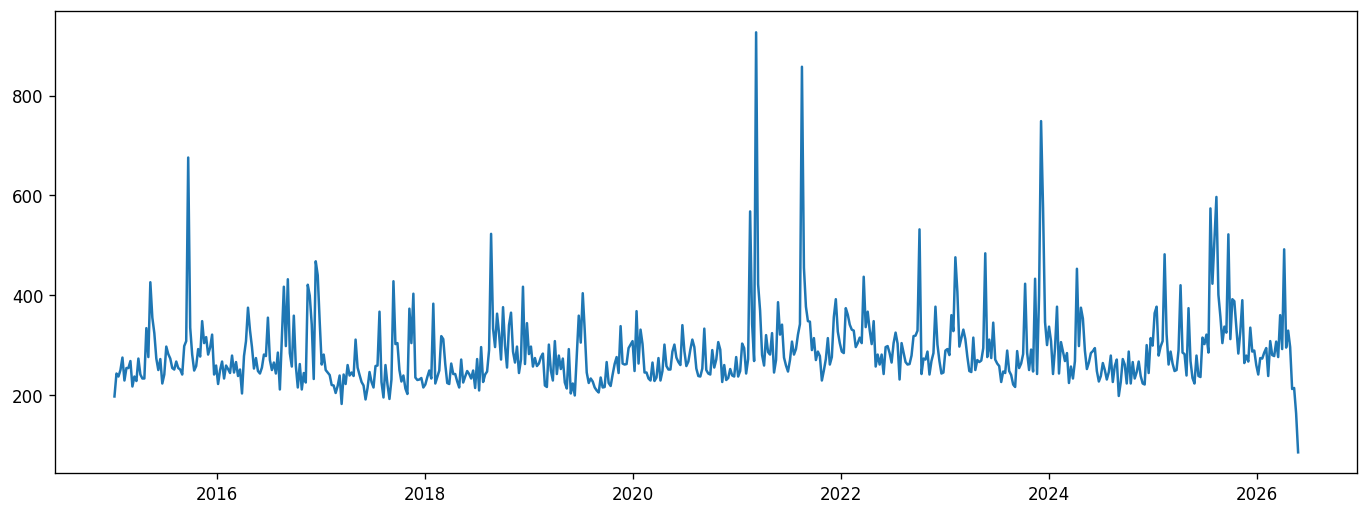

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(weekly["date"], weekly["nb_seismes"])
plt.show()

##  Feature Engineering Sismologique

Au-delà du simple nombre de séismes, nous construisons de nouveaux indicateurs permettant de mieux représenter l'intensité de l'activité sismique.

In [14]:
# L'énergie libérée est proportionnelle à 10^(1.5 * mag)
df["energy"] = 10 ** (1.5 * df["mag"])

# S'assurer que la date est bien en datetime
df["date"] = pd.to_datetime(df["date"])

# Agrégation hebdomadaire de l'énergie
weekly_energy = (
    df.resample("W-MON", on="date")["energy"]
    .sum()
    .reset_index()
)

weekly_energy.columns = ["date", "energy_sum"]

# Fusion avec le dataframe weekly
weekly = weekly.merge(weekly_energy, on="date", how="left")

# Remplacer les valeurs manquantes
weekly["energy_sum"] = weekly["energy_sum"].fillna(0)

# Affichage propre des dernières lignes
weekly[["date", "nb_seismes", "energy_sum"]].tail(5)

,date,nb_seismes,energy_sum
589,2026-04-27,296,5.537116e+09
590,2026-05-04,212,4.414205e+09
591,2026-05-11,214,7.139173e+09
592,2026-05-18,163,1.770111e+10
593,2026-05-25,85,1.368069e+10


In [14]:
!pip install hdbscan

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
    --------------------------------------- 0.0/1.9 MB 660.6 kB/s eta 0:00:03
    --------------------------------------- 0.0/1.9 MB 393.8 kB/s eta 0:00:05
   - -------------------------------------- 0.1/1.9 MB 655.4 kB/s eta 0:00:03
   ---- ----------------------------------- 0.2/1.9 MB 787.7 kB/s eta 0:00:03
   ------ --------------------------------- 0.3/1.9 MB 855.7 kB/s eta 0:00:02
   ------ --------------------------------- 0.3/1.9 MB 855.7 kB/s eta 0:00:02
   ------- -------------------------------- 0.4/1.9 MB 768.6 kB/s eta 0:00:03
   -------- ------------------------------- 0.4/1.9 MB 755.6 kB/s eta 0:00:03
   --------- ------------------------------ 0.5/1.9 MB 775.8 kB/s eta 0:00:02
   ------------ --------------------------- 0.6/1.9 MB 797.6 kB/s eta 0:00:02
   ------------- -------------------------- 0.6/1.9 MB 816.5 kB/s eta 0:00:02
   -

  You can safely remove it manually.


In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. sample (مهم بزاف)
df_geo = df[["latitude", "longitude"]].dropna().sample(20000, random_state=42)

# 2. scaling
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(df_geo)

# 3. clustering خفيف
kmeans = KMeans(n_clusters=10, random_state=42)
df_geo["cluster"] = kmeans.fit_predict(coords_scaled)

print(df_geo["cluster"].value_counts())

cluster
0    4728
9    2525
6    2476
4    1898
3    1707
2    1653
5    1607
1    1572
7     953
8     881
Name: count, dtype: int64


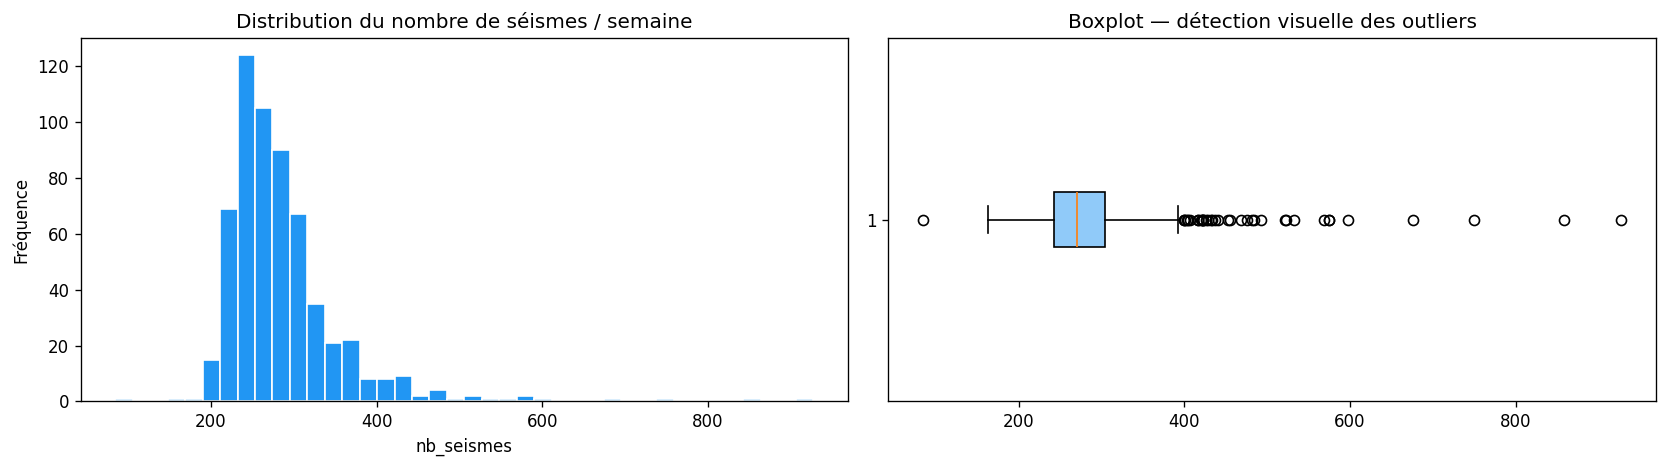

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(weekly["nb_seismes"], bins=40, color="#2196F3", edgecolor="white")
axes[0].set_title("Distribution du nombre de séismes / semaine")
axes[0].set_xlabel("nb_seismes")
axes[0].set_ylabel("Fréquence")

axes[1].boxplot(weekly["nb_seismes"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="#90CAF9"))
axes[1].set_title("Boxplot — détection visuelle des outliers")

plt.tight_layout()
plt.show()

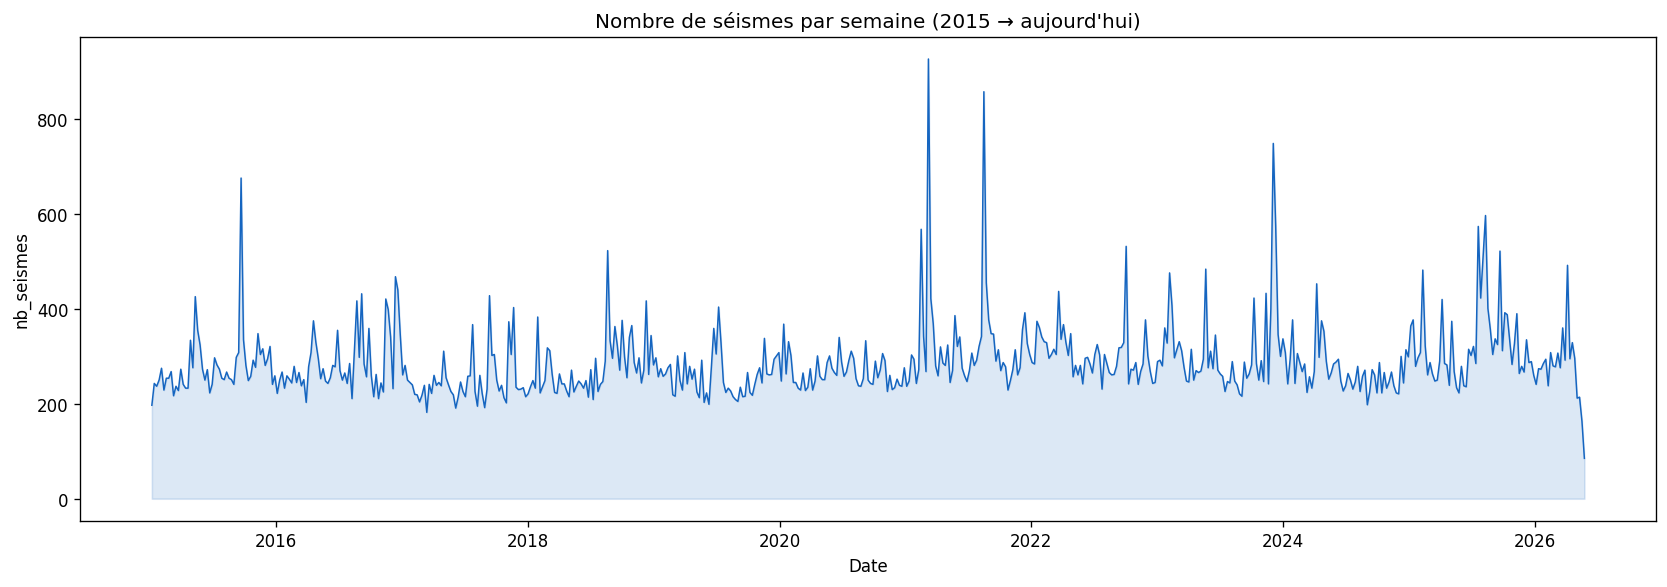

In [17]:
plt.figure()
plt.plot(weekly["date"], weekly["nb_seismes"], linewidth=0.9, color="#1565C0")
plt.fill_between(weekly["date"], weekly["nb_seismes"], alpha=0.15, color="#1565C0")
plt.title("Nombre de séismes par semaine (2015 → aujourd'hui)")
plt.xlabel("Date")
plt.ylabel("nb_seismes")
plt.tight_layout()
plt.show()

##  Décomposition de la série temporelle

La méthode STL permet de séparer la série en trois composantes :

- Tendance
- Saisonnalité
- Résidu

Cette analyse facilite la compréhension des dynamiques temporelles du phénomène étudié.

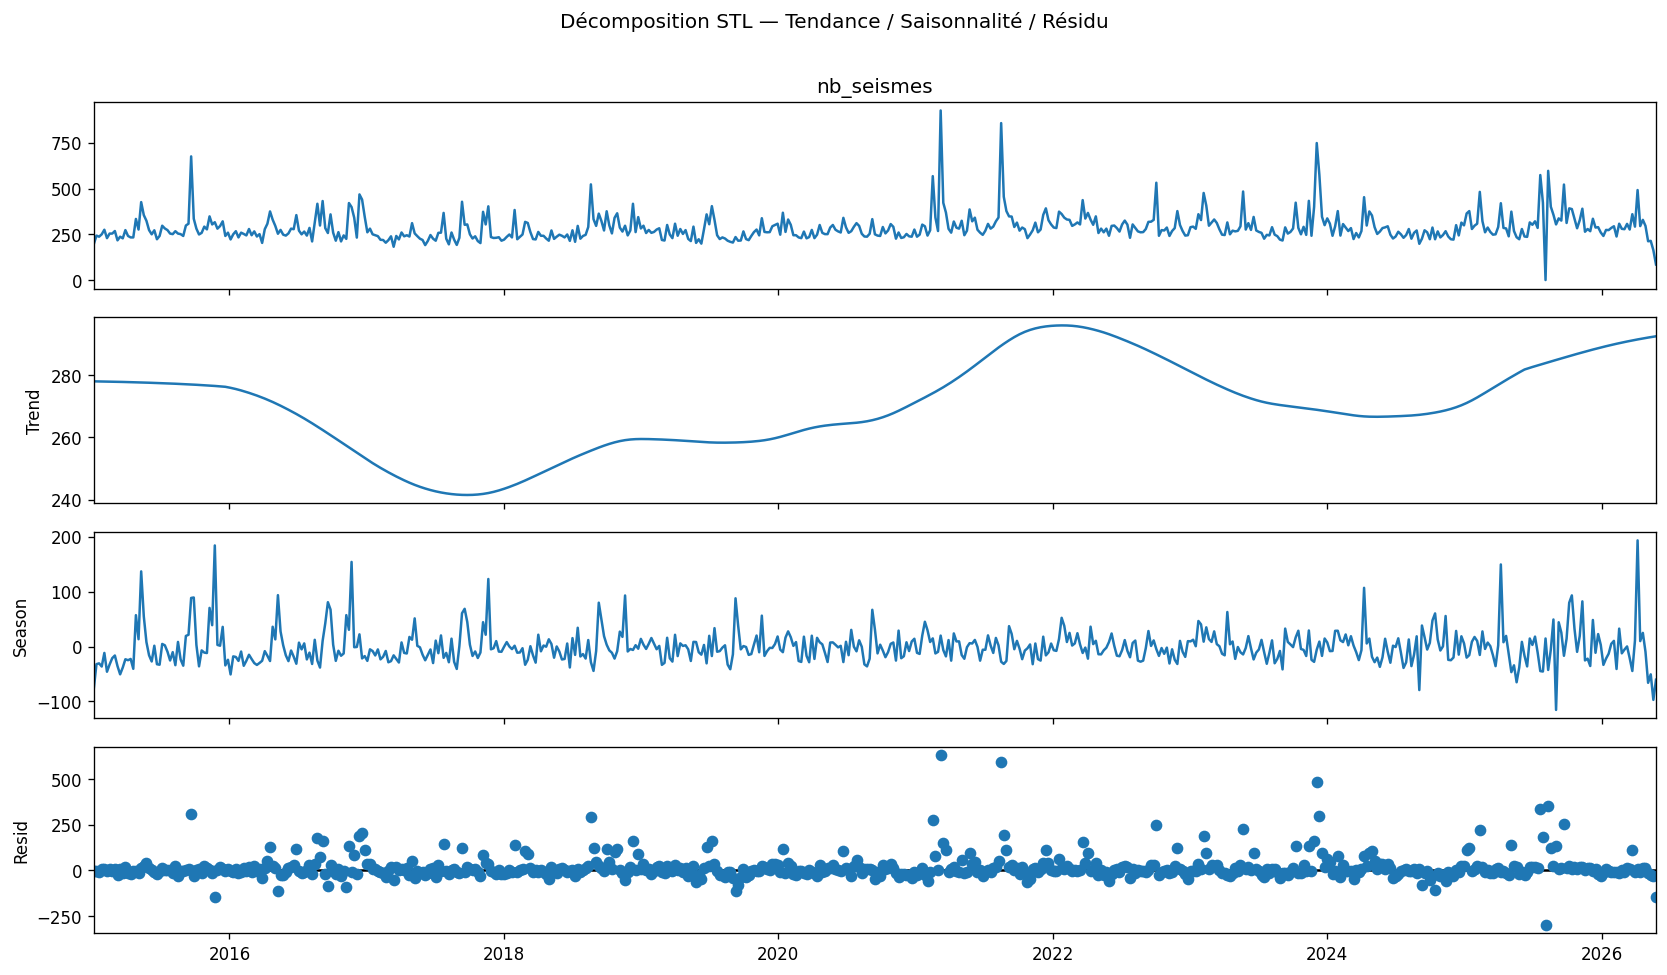

In [18]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# 1. Trier
weekly = weekly.sort_values("date")

# 2. Construire une série propre
series = weekly.set_index("date")["nb_seismes"]

# 3. Forcer fréquence + gérer les trous
series = series.asfreq("W-MON").fillna(0)

# 4. STL
stl = STL(series, period=52, robust=True)
result = stl.fit()

# 5. Plot
fig = result.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Décomposition STL — Tendance / Saisonnalité / Résidu", y=1.01)
plt.tight_layout()
plt.show()

## Analyse de la stationnarité

La stationnarité constitue une condition importante pour plusieurs modèles de prévision temporelle.

Le test d'Augmented Dickey-Fuller (ADF) est utilisé pour vérifier cette propriété.

In [19]:
adf_result = adfuller(series.dropna(), autolag="AIC")

print("── Test ADF (Augmented Dickey-Fuller) ──────────────────")
print(f"  Statistique ADF : {adf_result[0]:.4f}")
print(f"  p-value         : {adf_result[1]:.4f}")
print(f"  Lags utilisés   : {adf_result[2]}")
print(f"  Valeurs critiques:")
for key, val in adf_result[4].items():
    print(f"    {key} : {val:.4f}")

if adf_result[1] < 0.05:
    print("\n✅ Série STATIONNAIRE — pas besoin de différenciation")
else:
    print("\n⚠️  Série NON STATIONNAIRE — appliquer une différenciation d'ordre 1")

── Test ADF (Augmented Dickey-Fuller) ──────────────────
  Statistique ADF : -9.5611
  p-value         : 0.0000
  Lags utilisés   : 2
  Valeurs critiques:
    1% : -3.4414
    5% : -2.8664
    10% : -2.5694

✅ Série STATIONNAIRE — pas besoin de différenciation


##  Analyse des dépendances temporelles

Les fonctions ACF et PACF permettent d'étudier les corrélations entre les observations passées et futures de la série.

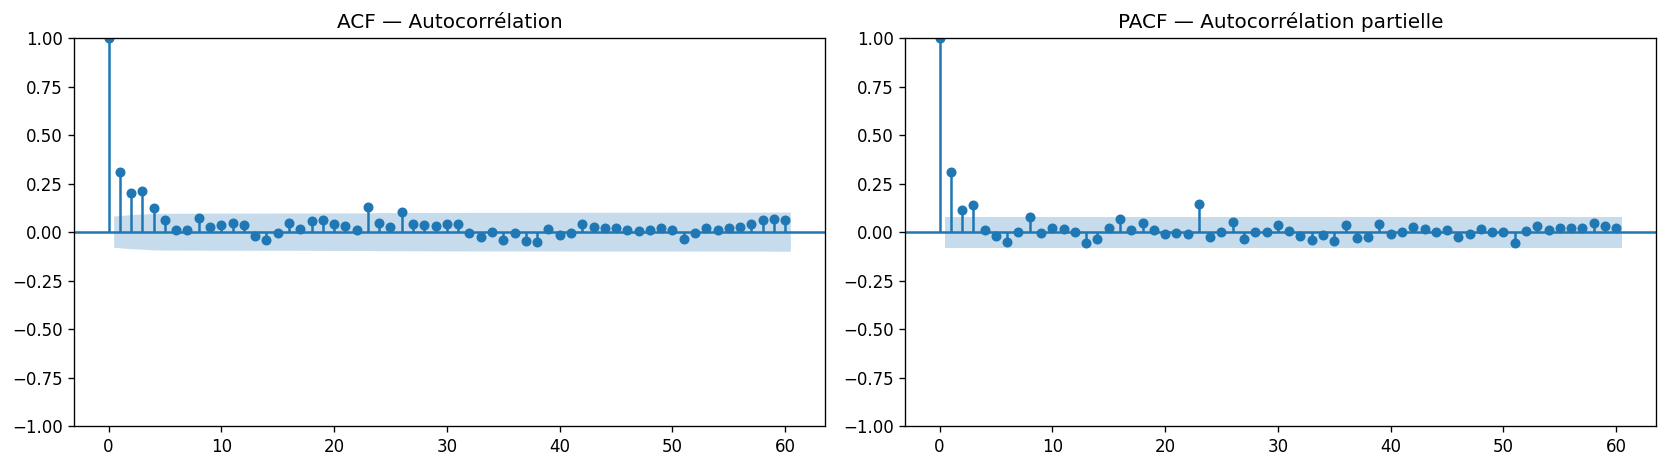

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(series.dropna(),  lags=60, ax=axes[0], title="ACF — Autocorrélation")
plot_pacf(series.dropna(), lags=60, ax=axes[1], title="PACF — Autocorrélation partielle")

plt.tight_layout()
plt.show()

##  Corrélation entre les variables temporelles

Nous analysons les relations entre les indicateurs hebdomadaires afin d'identifier les variables les plus pertinentes pour la prévision.

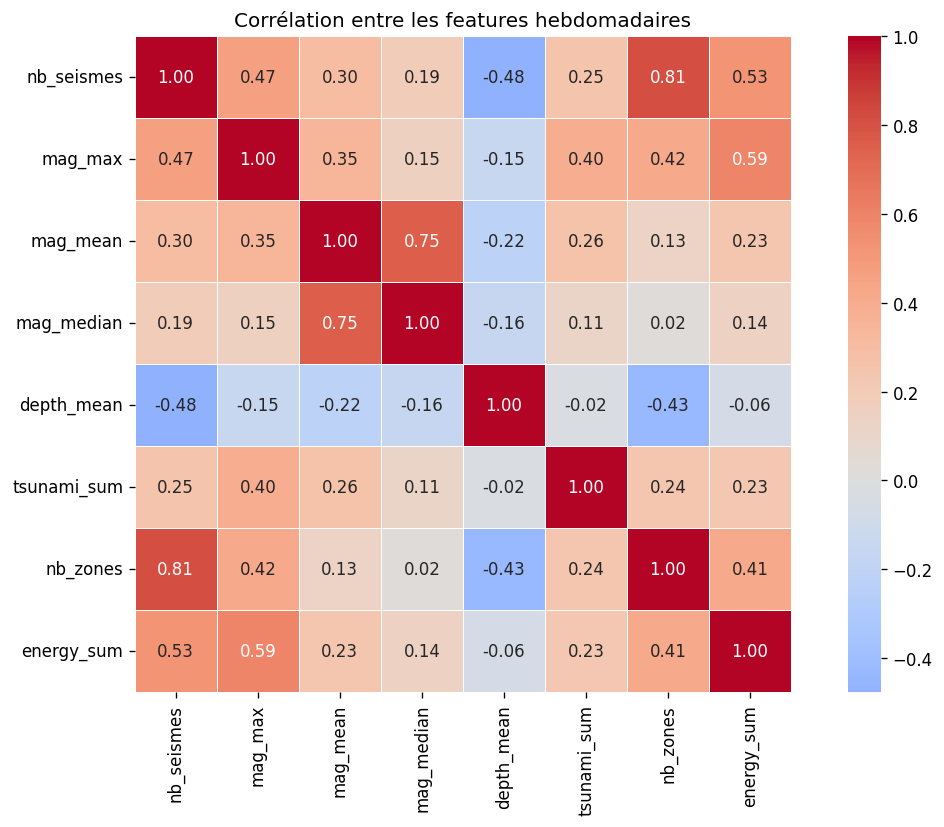

In [21]:
features_corr = weekly[[
    "nb_seismes", "mag_max", "mag_mean", "mag_median",
    "depth_mean", "tsunami_sum", "nb_zones", "energy_sum"
]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(features_corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Corrélation entre les features hebdomadaires")
plt.tight_layout()
plt.show()

In [22]:
print("══════════════════════════════════════════")
print("  DATASET HEBDOMADAIRE — RÉSUMÉ FINAL")
print("══════════════════════════════════════════")
print(f"  Semaines totales  : {len(weekly)}")
print(f"  Période           : {weekly['date'].min().date()} → {weekly['date'].max().date()}")
print(f"  Séismes / semaine : min={weekly['nb_seismes'].min()}  "
      f"max={weekly['nb_seismes'].max()}  "
      f"moy={weekly['nb_seismes'].mean():.1f}")
print(f"  Valeurs manquantes: {weekly.isnull().sum().sum()}")
print("══════════════════════════════════════════")
weekly.head()

══════════════════════════════════════════
  DATASET HEBDOMADAIRE — RÉSUMÉ FINAL
══════════════════════════════════════════
  Semaines totales  : 594
  Période           : 2015-01-05 → 2026-05-25
  Séismes / semaine : min=85  max=927  moy=286.6
  Valeurs manquantes: 0
══════════════════════════════════════════


,date,nb_seismes,mag_max,mag_mean,mag_median,depth_mean,tsunami_sum,nb_zones,nb_seismes_clean,energy_sum
0,2015-01-05,197,5.6,4.482792,4.4,74.227010,5,167,197,2.560355e+09
1,2015-01-12,243,6.5,4.502881,4.4,88.835140,2,205,243,1.004695e+10
2,2015-01-19,237,5.7,4.515443,4.5,104.892907,3,197,237,3.612158e+09
3,2015-01-26,250,6.8,4.472120,4.4,88.609612,4,213,250,1.878276e+10
4,2015-02-02,275,6.3,4.523527,4.4,91.872175,7,223,275,1.136276e+10


📓 02 — Feature Engineering

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

In [25]:
# On repart du weekly déjà construit dans le preprocessing
# Si tu relances le notebook, assure-toi que weekly est en mémoire
# Sinon : weekly = pd.read_csv("weekly_clean.csv", parse_dates=["date"])

print(f"Shape de départ : {weekly.shape}")
print(f"Colonnes : {weekly.columns.tolist()}")
weekly.head(3)

Shape de départ : (594, 10)
Colonnes : ['date', 'nb_seismes', 'mag_max', 'mag_mean', 'mag_median', 'depth_mean', 'tsunami_sum', 'nb_zones', 'nb_seismes_clean', 'energy_sum']


,date,nb_seismes,mag_max,mag_mean,mag_median,depth_mean,tsunami_sum,nb_zones,nb_seismes_clean,energy_sum
0,2015-01-05,197,5.6,4.482792,4.4,74.227010,5,167,197,2.560355e+09
1,2015-01-12,243,6.5,4.502881,4.4,88.835140,2,205,243,1.004695e+10
2,2015-01-19,237,5.7,4.515443,4.5,104.892907,3,197,237,3.612158e+09


### Les séismes ont une mémoire : la semaine précédente influence la suivante

In [ ]:
# Lag 1 = semaine d'avant, lag 4 = 1 mois, lag 52 = même semaine l'année d'avant

for lag in [1, 2, 3, 4, 8, 12, 52]:
    weekly[f"lag_{lag}"] = weekly["nb_seismes"].shift(lag)

# Lag sur energy_sum (signal fort identifié dans l'EDA)
for lag in [1, 2, 4]:
    weekly[f"energy_lag_{lag}"] = weekly["energy_sum"].shift(lag)

# Lag sur nb_zones (corrélation 0.88)
for lag in [1, 2]:
    weekly[f"zones_lag_{lag}"] = weekly["nb_zones"].shift(lag)

print("Lags créés ✅")
weekly[[c for c in weekly.columns if "lag" in c]].head(10)

Lags créés ✅


,lag_1,lag_2,lag_3,lag_4,lag_8,lag_12,lag_52,energy_lag_1,energy_lag_2,energy_lag_4,zones_lag_1,zones_lag_2
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,197.0,NaN,NaN,NaN,NaN,NaN,NaN,2.560355e+09,NaN,NaN,167.0,NaN
2,243.0,197.0,NaN,NaN,NaN,NaN,NaN,1.004695e+10,2.560355e+09,NaN,205.0,167.0
3,237.0,243.0,197.0,NaN,NaN,NaN,NaN,3.612158e+09,1.004695e+10,NaN,197.0,205.0
4,250.0,237.0,243.0,197.0,NaN,NaN,NaN,1.878276e+10,3.612158e+09,2.560355e+09,213.0,197.0
5,275.0,250.0,237.0,243.0,NaN,NaN,NaN,1.136276e+10,1.878276e+10,1.004695e+10,223.0,213.0
6,229.0,275.0,250.0,237.0,NaN,NaN,NaN,3.047816e+09,1.136276e+10,3.612158e+09,198.0,223.0
7,254.0,229.0,275.0,250.0,NaN,NaN,NaN,7.432200e+10,3.047816e+09,1.878276e+10,221.0,198.0
8,254.0,254.0,229.0,275.0,197.0,NaN,NaN,1.471462e+10,7.432200e+10,1.136276e+10,217.0,221.0
9,268.0,254.0,254.0,229.0,243.0,NaN,NaN,3.716643e+10,1.471462e+10,3.047816e+09,226.0,217.0


In [27]:
# Moyenne mobile : capture la tendance récente
for w in [4, 8, 12, 26]:
    weekly[f"rolling_mean_{w}"] = weekly["nb_seismes"].shift(1).rolling(w).mean()

# Écart-type glissant : capture la volatilité / instabilité sismique
for w in [4, 8, 12]:
    weekly[f"rolling_std_{w}"] = weekly["nb_seismes"].shift(1).rolling(w).std()

# Rolling max : détecte les périodes de forte activité récente
for w in [4, 8]:
    weekly[f"rolling_max_{w}"] = weekly["nb_seismes"].shift(1).rolling(w).max()

# Rolling sur energy_sum (signal fort)
weekly["energy_rolling_4"] = weekly["energy_sum"].shift(1).rolling(4).mean()
weekly["energy_rolling_8"] = weekly["energy_sum"].shift(1).rolling(8).mean()

print("Rolling features créés ✅")

Rolling features créés ✅


### Encodage cyclique de la semaine (sin/cos) — meilleur que l'entier brut


In [ ]:
weekly["week_of_year"] = weekly["date"].dt.isocalendar().week.astype(int)
weekly["month"]        = weekly["date"].dt.month
weekly["quarter"]      = weekly["date"].dt.quarter
weekly["year"]         = weekly["date"].dt.year

weekly["week_sin"] = np.sin(2 * np.pi * weekly["week_of_year"] / 52)
weekly["week_cos"] = np.cos(2 * np.pi * weekly["week_of_year"] / 52)

weekly["month_sin"] = np.sin(2 * np.pi * weekly["month"] / 12)
weekly["month_cos"] = np.cos(2 * np.pi * weekly["month"] / 12)

print("Features calendaires créés ✅")
weekly[["date", "week_of_year", "week_sin", "week_cos", "month", "quarter"]].head(5)

Features calendaires créés ✅


,date,week_of_year,week_sin,week_cos,month,quarter
0,2015-01-05,2,0.239316,0.970942,1,1
1,2015-01-12,3,0.354605,0.935016,1,1
2,2015-01-19,4,0.464723,0.885456,1,1
3,2015-01-26,5,0.568065,0.822984,1,1
4,2015-02-02,6,0.663123,0.748511,2,1


In [29]:
# Ratio énergie / nombre de séismes = énergie moyenne par événement
weekly["energy_per_seisme"] = weekly["energy_sum"] / (weekly["nb_seismes"] + 1)

# Ratio tsunami = proportion de séismes tsunamigéniques
weekly["tsunami_ratio"] = weekly["tsunami_sum"] / (weekly["nb_seismes"] + 1)

# Écart entre mag_max et mag_mean = hétérogénéité de la semaine
weekly["mag_spread"] = weekly["mag_max"] - weekly["mag_mean"]

# Variation du nb_seismes par rapport à la semaine précédente
weekly["delta_seismes"] = weekly["nb_seismes"].diff(1)

# Log de l'énergie (réduit l'effet des pics extrêmes)
weekly["log_energy"] = np.log1p(weekly["energy_sum"])

print("Features physiques créés ✅")
weekly[["date", "energy_per_seisme", "tsunami_ratio", "mag_spread",
        "delta_seismes", "log_energy"]].tail(5)

Features physiques créés ✅


,date,energy_per_seisme,tsunami_ratio,mag_spread,delta_seismes,log_energy
589,2026-04-27,1.864349e+07,0.0,1.629966,-33.0,22.434740
590,2026-05-04,2.072397e+07,0.0,1.481792,-84.0,22.208094
591,2026-05-11,3.320545e+07,0.0,1.558111,2.0,22.688863
592,2026-05-18,1.079336e+08,0.0,2.081104,-51.0,23.596893
593,2026-05-25,1.590777e+08,0.0,1.831294,-78.0,23.339251


In [30]:
# Les lags créent des NaN sur les premières semaines — on les supprime
before = len(weekly)
weekly_model = weekly.dropna().reset_index(drop=True)
after  = len(weekly_model)

print(f"Lignes supprimées (NaN dus aux lags) : {before - after}")
print(f"Lignes restantes pour la modélisation : {after}")
print(f"Semaines : {weekly_model['date'].min().date()} → {weekly_model['date'].max().date()}")

Lignes supprimées (NaN dus aux lags) : 52
Lignes restantes pour la modélisation : 542
Semaines : 2016-01-04 → 2026-05-25


In [31]:
# Features retenues selon les insights de l'EDA :
FEATURES = [
    "lag_1", "lag_2", "lag_3", "lag_4", "lag_8", "lag_12", "lag_52",
    "energy_lag_1", "energy_lag_2", "energy_lag_4",
    "zones_lag_1", "zones_lag_2",
    "rolling_mean_4", "rolling_mean_8", "rolling_mean_12", "rolling_mean_26",
    "rolling_std_4", "rolling_std_8",
    "rolling_max_4", "rolling_max_8",
    "energy_rolling_4", "energy_rolling_8",
    "mag_max", "mag_spread", "depth_mean",
    "energy_per_seisme", "log_energy",
    "nb_zones",
    "week_sin", "week_cos", "month_sin", "month_cos", "quarter",
]

TARGET = "nb_seismes"

# 🔥 garder uniquement les features existantes
FEATURES = [f for f in FEATURES if f in weekly_model.columns]

X = weekly_model[FEATURES]
y = weekly_model[TARGET]

print(f"Features sélectionnées : {len(FEATURES)}")
print(f"Cible : {TARGET}")
print(f"Shape X : {X.shape}")

Features sélectionnées : 33
Cible : nb_seismes
Shape X : (542, 33)


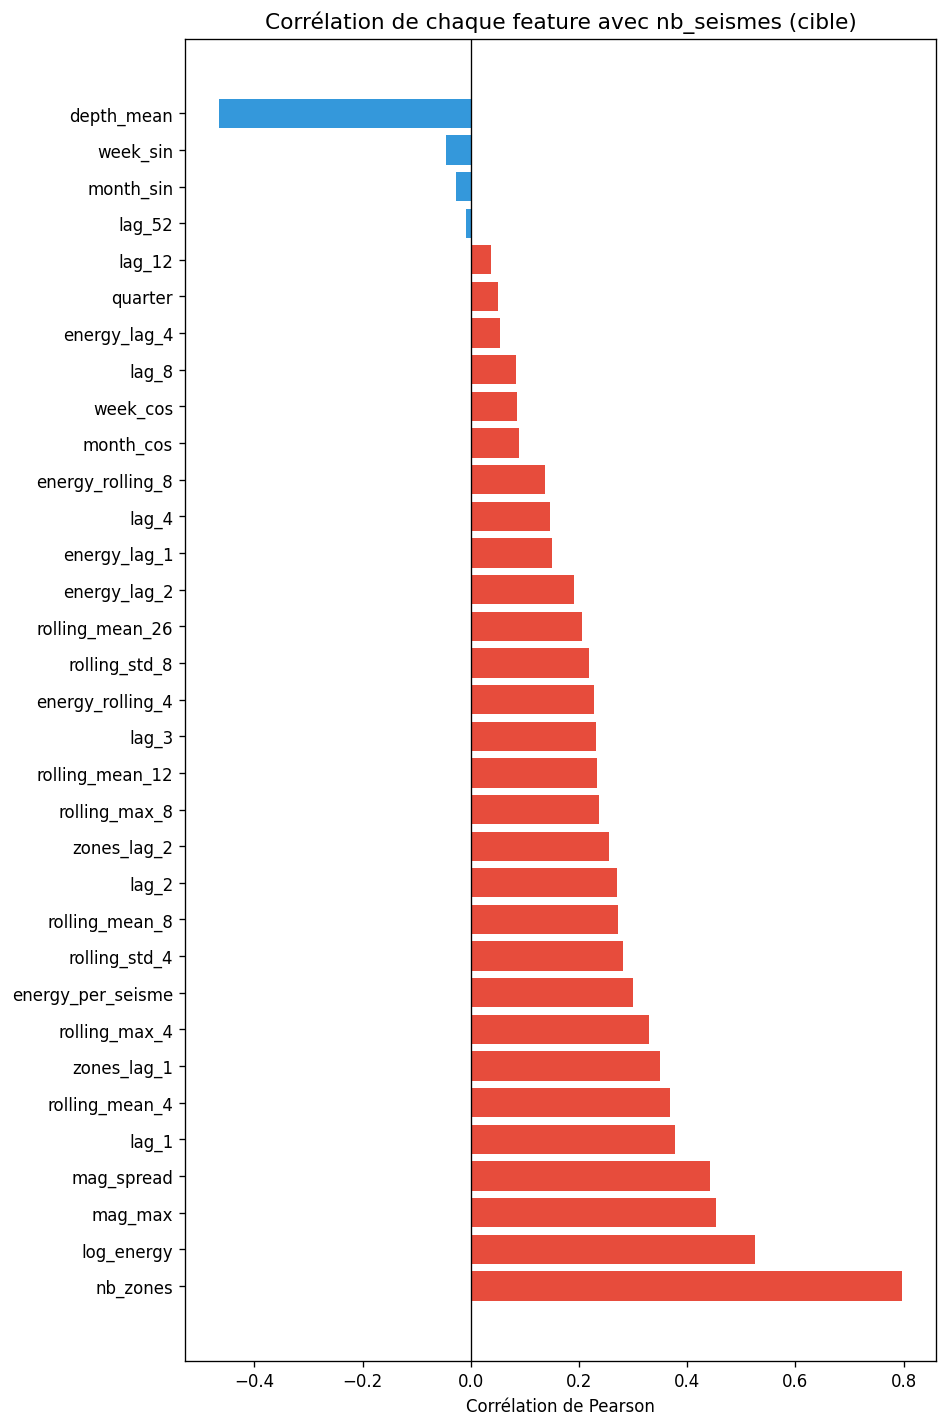

In [32]:
corr_with_target = (
    weekly_model[FEATURES + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 12))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Corrélation de chaque feature avec nb_seismes (cible)", fontsize=13)
plt.xlabel("Corrélation de Pearson")
plt.tight_layout()
plt.show()

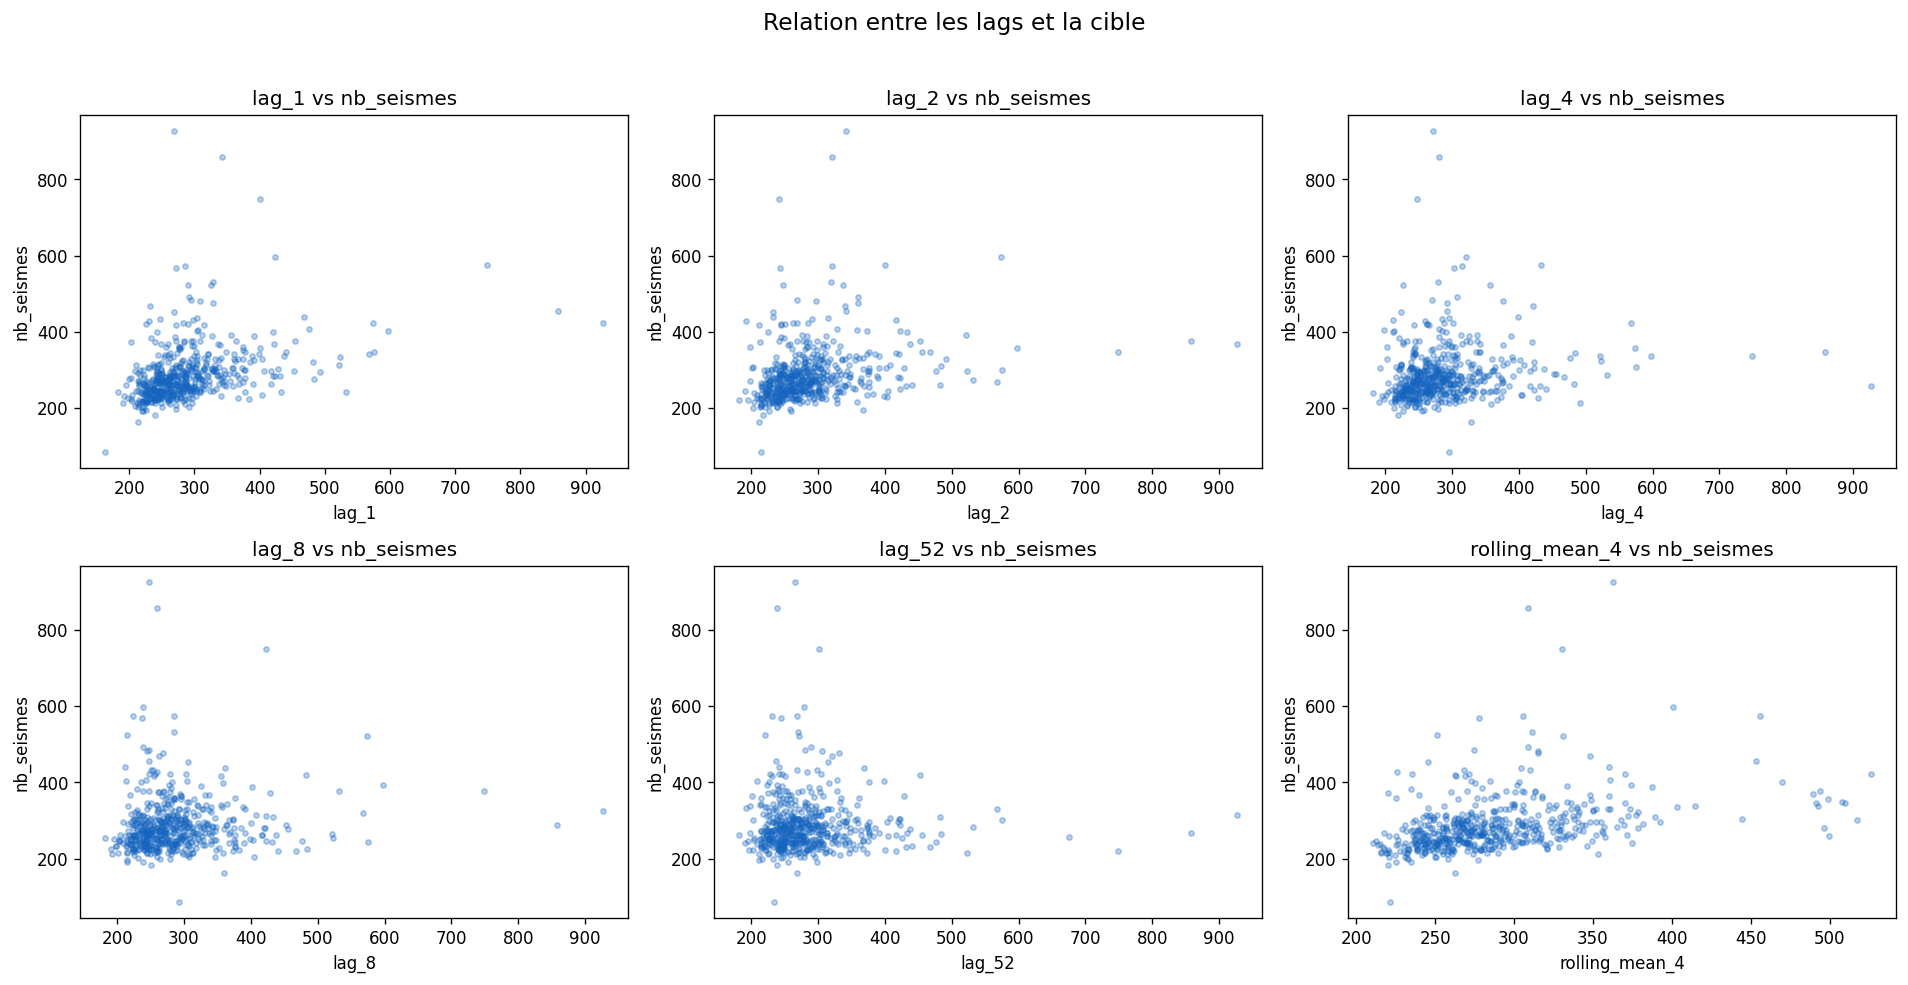

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

top_lags = ["lag_1", "lag_2", "lag_4", "lag_8", "lag_52", "rolling_mean_4"]

for i, feat in enumerate(top_lags):
    axes[i].scatter(weekly_model[feat], weekly_model[TARGET],
                    alpha=0.3, s=10, color="#1565C0")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("nb_seismes")
    axes[i].set_title(f"{feat} vs nb_seismes")

plt.suptitle("Relation entre les lags et la cible", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [34]:
print("══════════════════════════════════════════════")
print("  DATASET PRÊT POUR LA MODÉLISATION")
print("══════════════════════════════════════════════")
print(f"  Semaines disponibles : {len(weekly_model)}")
print(f"  Nombre de features   : {len(FEATURES)}")
print(f"  Cible                : {TARGET}")
print(f"  Période              : {weekly_model['date'].min().date()} → {weekly_model['date'].max().date()}")
print(f"  Valeurs manquantes   : {X.isnull().sum().sum()}")
print(f"\n  Top 5 features les plus corrélées :")
print(corr_with_target.head(5).to_string())
print("══════════════════════════════════════════════")

══════════════════════════════════════════════
  DATASET PRÊT POUR LA MODÉLISATION
══════════════════════════════════════════════
  Semaines disponibles : 542
  Nombre de features   : 33
  Cible                : nb_seismes
  Période              : 2016-01-04 → 2026-05-25
  Valeurs manquantes   : 0

  Top 5 features les plus corrélées :
nb_zones      0.796709
log_energy    0.524388
mag_max       0.454076
mag_spread    0.442524
lag_1         0.377708
══════════════════════════════════════════════


📓 03 — Modélisation

In [60]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 2.2 MB/s eta 0:00:46
    --------------------------------------- 1.6/101.7 MB 2.4 MB/s eta 0:00:42
    --------------------------------------- 2.4/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 2.9/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.4/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.9/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 4.5/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 5.0/101.7 MB 2.4 MB/s eta 0:00:40
   -- ------------------------------------- 5.5/101.7 MB 2.4 MB/s eta 0:00:40
   -- ------------------------------------- 6.3/101.7 MB 2.4 MB/s eta 0:00:40


In [63]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 1.1 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.2 MB ? eta -:--:--
    --------------------------------------- 0.5/39.2 MB 1.1 MB/s eta 0:00:36
    --------------------------------------- 0.5/39.2 MB 1.1 MB/s eta 0:00:36
    --------------------------------------- 0.8/39.2 MB 990.3 kB/s eta 0:00:39
   - -------------------------------------- 1.3/39.2 MB 1.1 MB/s eta 0:00:35
   - -------------------------------------- 1.6/39.2 MB 1.1 MB/s eta 0:00:34
   -- ------------------------------------- 2.1/39.2 MB 1.2 MB/s eta 0:00:31
   -- --------------------

In [62]:
!pip install lightgbm 

Defaulting to user installation because normal site-packages is not writeable
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [105]:
import subprocess
subprocess.run(["pip", "install", "tensorflow"], capture_output=True)
print("✅ TensorFlow installé — relance la Cellule 1")

✅ TensorFlow installé — relance la Cellule 1


In [109]:
import subprocess
subprocess.run(["pip", "install", "tensorflow-cpu"], capture_output=True)
print("✅ TensorFlow CPU installé")

✅ TensorFlow CPU installé


In [81]:
import sys
!{sys.executable} -m pip uninstall scikit-learn -y
!{sys.executable} -m pip install scikit-learn --upgrade

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)


In [85]:
import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

In [5]:
import sys
!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.8 kB 119.1 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/60.8 kB 119.1 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/60.8 kB 115.5 kB/s eta 0:00:01
     -------------------------------------- 60.

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 5.29.6 which is incompatible.
streamlit 1.32.0 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

import xgboost as xgb
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import shap

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

### Sélection basée sur tes graphiques SHAP + corrélation Pearson

In [ ]:
# ❌ Supprimées : lag_52, lag_8, lag_12, month_sin/cos, week_cos, quarter

FEATURES = [
    # Spatial — feature dominante
    "nb_zones",
    # Energie — fort signal
    "energy_per_seisme", "log_energy",
    "energy_lag_1", "energy_rolling_4",
    # Magnitude
    "mag_max", "mag_spread",
    # Profondeur
    "depth_mean",
    # Mémoire temporelle courte (confirmée par SHAP)
    "lag_1", "lag_2", "lag_3",
    # Rolling — tendance locale
    "rolling_mean_4", "rolling_mean_8", "rolling_mean_26",
    "rolling_std_8", "rolling_max_4",
    # Zones lags
    "zones_lag_1", "zones_lag_2",
    # Saisonnalité (weak mais gardée)
    "week_sin",
]

TARGET = "nb_seismes"

X = weekly_model[FEATURES].values
y = weekly_model[TARGET].values
dates = weekly_model["date"].values

print(f"Features retenues : {len(FEATURES)}")
print(f"Observations      : {len(X)}")

Features retenues : 19
Observations      : 542


### 52 dernières semaines = jeu de test final (jamais touché pendant l'entraînement)


In [ ]:
split_idx = len(weekly_model) - 52

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train     = dates[:split_idx]
dates_test      = dates[split_idx:]

print(f"Train : {len(X_train)} semaines → {dates_train[0]} : {dates_train[-1]}")
print(f"Test  : {len(X_test)}  semaines → {dates_test[0]} : {dates_test[-1]}")

Train : 490 semaines → 2016-01-04T00:00:00 : 2025-05-19T00:00:00
Test  : 52  semaines → 2025-05-26T00:00:00 : 2026-05-25T00:00:00


In [38]:
results = []

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100

    print(f"\n── {name} ──────────────────────────────────────")
    print(f"  MAE  : {mae:.1f} séismes d'erreur en moyenne")
    print(f"  RMSE : {rmse:.1f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")

    results.append({"Modèle": name, "MAE": round(mae,1),
                    "RMSE": round(rmse,1), "R²": round(r2,4),
                    "MAPE%": round(mape,2)})
    return y_pred

In [39]:
# Référence minimale : prédire = semaine précédente
# Si aucun modèle ne bat ça, ils ne servent à rien

y_pred_naive = X_test[:, FEATURES.index("lag_1")]
evaluate("Baseline naïf (lag_1)", y_test, y_pred_naive)


── Baseline naïf (lag_1) ──────────────────────────────────────
  MAE  : 64.1 séismes d'erreur en moyenne
  RMSE : 91.9
  R²   : -0.0584
  MAPE : 19.91%


array([234., 223., 279., 238., 236., 315., 302., 321., 285., 574., 423.,
       597., 401., 357., 304., 337., 325., 522., 312., 392., 388., 336.,
       283., 327., 390., 264., 279., 267., 335., 287., 289., 260., 241.,
       274., 273., 285., 294., 238., 308., 280., 278., 307., 276., 360.,
       292., 492., 295., 329., 296., 212., 214., 163.])

In [40]:
# ARIMApur sur la série — AR(2) confirmé par le PACF
# Pas de features exogènes ici, seulement la série temporelle

series_train = y_train.copy()
series_test  = y_test.copy()

arima = ARIMA(series_train, order=(2, 0, 1))
arima_fit = arima.fit()

y_pred_arima = arima_fit.forecast(steps=52)
y_pred_arima = np.clip(y_pred_arima, 0, None)

evaluate("ARIMA(2,0,1)", y_test, y_pred_arima)


── ARIMA(2,0,1) ──────────────────────────────────────
  MAE  : 59.3 séismes d'erreur en moyenne
  RMSE : 93.5
  R²   : -0.0941
  MAPE : 20.08%


array([271.39702821, 276.46530103, 278.73278842, 280.30476148,
       281.45412995, 282.29861339, 282.91935511, 283.37565185,
       283.711069  , 283.95762939, 284.13887243, 284.27210162,
       284.37003651, 284.44202705, 284.49494629, 284.53384646,
       284.56244143, 284.58346118, 284.59891251, 284.61027056,
       284.6186197 , 284.62475703, 284.6292685 , 284.63258482,
       284.6350226 , 284.63681457, 284.63813183, 284.63910012,
       284.6398119 , 284.64033512, 284.64071973, 284.64100246,
       284.64121028, 284.64136305, 284.64147535, 284.6415579 ,
       284.64161858, 284.64166318, 284.64169597, 284.64172008,
       284.64173779, 284.64175082, 284.64176039, 284.64176743,
       284.6417726 , 284.6417764 , 284.6417792 , 284.64178125,
       284.64178277, 284.64178388, 284.64178469, 284.64178529])

In [41]:
# SARIMA = ARIMA + composante saisonnière
# Saisonnalité faible mais réelle (STL l'a détectée) → S=52

sarima = SARIMAX(
    series_train,
    order=(2, 0, 1),
    seasonal_order=(1, 0, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima.fit(disp=False)

y_pred_sarima = sarima_fit.forecast(steps=52)
y_pred_sarima = np.clip(y_pred_sarima, 0, None)

evaluate("SARIMA(2,0,1)(1,0,0)[52]", y_test, y_pred_sarima)


── SARIMA(2,0,1)(1,0,0)[52] ──────────────────────────────────────
  MAE  : 58.5 séismes d'erreur en moyenne
  RMSE : 91.7
  R²   : -0.0519
  MAPE : 20.39%


array([273.27423076, 285.20011162, 288.81672675, 290.3598345 ,
       290.94074682, 291.02915105, 290.9247705 , 291.13017656,
       291.37064967, 291.32828561, 291.13662563, 291.65549316,
       291.47191674, 291.44535708, 292.12949276, 291.97901603,
       291.67981463, 291.85166603, 292.24665947, 291.79877825,
       292.40867237, 292.13437337, 292.48813756, 292.46179408,
       292.36936336, 292.69013976, 292.89524676, 292.99294807,
       292.4213124 , 292.96529799, 292.4680803 , 292.67329912,
       292.21744467, 292.19132477, 293.08249749, 293.01510391,
       293.0055786 , 291.64909332, 293.0527048 , 293.63823284,
       293.50484178, 293.78465794, 293.99012329, 294.05512826,
       293.80613524, 292.81343208, 294.01063074, 294.11704404,
       294.55402765, 293.52009592, 294.47773733, 294.84041515])

In [42]:
# Lissage exponentiel avec tendance + saisonnalité
# Bon baseline pour séries avec patterns réguliers

hw = ExponentialSmoothing(
    series_train,
    trend="add",
    seasonal="add",
    seasonal_periods=52
)
hw_fit = hw.fit(optimized=True)

y_pred_hw = hw_fit.forecast(steps=52)
y_pred_hw = np.clip(y_pred_hw, 0, None)

evaluate("Holt-Winters (ETS)", y_test, y_pred_hw)


── Holt-Winters (ETS) ──────────────────────────────────────
  MAE  : 63.1 séismes d'erreur en moyenne
  RMSE : 97.0
  R²   : -0.1778
  MAPE : 21.27%


array([257.81751739, 271.133657  , 273.62018107, 293.58802459,
       263.64232881, 274.13181172, 287.0818061 , 271.82920801,
       255.87383098, 256.87557352, 283.77562162, 358.52621305,
       277.42081874, 284.58977347, 299.64564771, 281.94964435,
       282.07551436, 285.41034571, 285.56586214, 275.02313473,
       260.25001087, 266.8905907 , 279.84820538, 274.74283435,
       331.70104233, 260.35178393, 278.67154928, 362.3475459 ,
       334.3718742 , 289.9465365 , 278.34219695, 281.0657739 ,
       293.61609031, 287.23630901, 310.66493444, 289.30034144,
       289.87801868, 340.10882408, 282.54150145, 272.5183792 ,
       344.31017771, 277.05780307, 275.01303625, 278.08882203,
       274.11752331, 328.01257469, 282.19860302, 296.12649578,
       274.85296907, 271.63563989, 269.1264298 , 292.06522153])

In [43]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = np.clip(rf.predict(X_test), 0, None)
evaluate("Random Forest", y_test, y_pred_rf)


── Random Forest ──────────────────────────────────────
  MAE  : 31.2 séismes d'erreur en moyenne
  RMSE : 39.4
  R²   : 0.8061
  MAPE : 11.73%


array([234.73777551, 284.66803183, 244.47702329, 224.72463278,
       291.44962721, 290.61519356, 322.16186462, 286.91630224,
       552.84088227, 467.45771252, 551.04447877, 470.7610896 ,
       418.07558452, 339.83525954, 383.15506119, 392.04403698,
       579.54423918, 374.02570994, 435.4292547 , 468.4284551 ,
       387.59521063, 302.98714722, 376.4508422 , 405.33017623,
       297.9950119 , 293.39573338, 278.84959895, 375.25561985,
       311.16573191, 303.80755615, 273.95427657, 276.18393363,
       294.61146168, 293.0101586 , 331.31612547, 329.31039554,
       253.52986474, 336.39766171, 292.64656277, 303.70672868,
       306.90594317, 284.70296313, 340.74756361, 307.67878647,
       417.89462657, 299.64094501, 340.60953415, 338.74245846,
       230.75093331, 236.04451634, 211.86424767, 204.86023193])

In [44]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric="rmse",
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = np.clip(xgb_model.predict(X_test), 0, None)
evaluate("XGBoost", y_test, y_pred_xgb)


── XGBoost ──────────────────────────────────────
  MAE  : 28.6 séismes d'erreur en moyenne
  RMSE : 41.5
  R²   : 0.7839
  MAPE : 11.36%


array([246.76819, 283.2754 , 250.7309 , 235.91818, 285.5812 , 286.5406 ,
       309.21234, 283.49734, 470.56586, 456.06226, 482.55762, 403.84146,
       408.32422, 329.36197, 349.70624, 360.5316 , 554.79395, 350.43994,
       368.54663, 430.53983, 350.99228, 300.06662, 352.7155 , 368.52036,
       296.11072, 289.8264 , 278.09027, 338.87875, 309.6585 , 300.91568,
       277.79794, 278.10065, 292.5642 , 290.0078 , 324.87244, 319.7137 ,
       257.3493 , 313.0385 , 287.11517, 295.59134, 298.42685, 278.2661 ,
       324.18634, 303.45212, 383.46793, 292.62286, 322.51978, 330.3639 ,
       244.58368, 246.60547, 235.11552, 235.05614], dtype=float32)

In [45]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    random_state=42,
    verbosity=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred_lgb = np.clip(lgb_model.predict(X_test), 0, None)
evaluate("LightGBM", y_test, y_pred_lgb)


── LightGBM ──────────────────────────────────────
  MAE  : 34.6 séismes d'erreur en moyenne
  RMSE : 49.8
  R²   : 0.6895
  MAPE : 12.68%


array([237.20193832, 274.56411629, 248.09061411, 223.33949543,
       279.65144674, 289.7082573 , 314.97633512, 281.20883011,
       447.98067007, 441.03386341, 430.23924653, 431.73547399,
       433.60745992, 335.68046501, 352.09378699, 444.62382436,
       478.32579072, 374.29933105, 399.75633742, 479.52403385,
       373.0422041 , 305.93759735, 378.17341443, 398.32766196,
       298.27835718, 292.15898272, 280.34329114, 381.21576977,
       316.19150083, 308.69103395, 280.08743432, 276.46760586,
       289.12048109, 292.42024529, 319.10562969, 322.10786069,
       258.05148416, 318.32297052, 290.07056888, 302.73536588,
       303.36943779, 276.72647976, 328.75623616, 298.97838378,
       424.46841414, 292.47221598, 325.18454247, 344.99030565,
       238.10456614, 240.33498238, 225.7003135 , 219.76807618])

In [135]:
# Normalisation obligatoire pour le LSTM
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1))

# Reshape pour LSTM : (samples, timesteps, features)
X_train_lstm = X_train_sc.reshape(X_train_sc.shape[0], 1, X_train_sc.shape[1])
X_test_lstm  = X_test_sc.reshape(X_test_sc.shape[0],  1, X_test_sc.shape[1])

# Architecture LSTM
model_lstm = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(1, X_train_sc.shape[1])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss", patience=15,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_lstm, y_train_sc,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

y_pred_lstm_sc = model_lstm.predict(X_test_lstm, verbose=0)
y_pred_lstm    = scaler_y.inverse_transform(y_pred_lstm_sc).flatten()
y_pred_lstm    = np.clip(y_pred_lstm, 0, None)

evaluate("LSTM", y_test, y_pred_lstm)


── LSTM ──────────────────────────────────────
  MAE  : 83.2 séismes d'erreur en moyenne
  RMSE : 183.6
  R²   : 0.2246
  MAPE : 26.09%


array([ 269.41766,  253.8078 ,  242.51971,  279.1058 ,  283.50656,
        299.3494 ,  280.94498,  559.431  ,  458.9504 , 1723.2095 ,
       1083.3732 ,  929.2549 , 1276.172  ,  812.2882 ,  302.83936,
        340.20474,  468.4542 ,  336.42038,  466.65427,  589.6677 ,
        422.1501 ,  341.70233,  408.0743 ,  449.8639 ,  320.4057 ,
        307.70187,  295.04858,  412.97852,  346.8452 ,  333.05255,
        276.01846,  297.8296 ,  316.00937,  310.84546,  324.1544 ,
        328.21317,  258.95218,  312.06845,  285.1785 ,  284.82587,
        293.7308 ,  275.44098,  334.6676 ,  312.5403 ,  440.20105,
        303.38202,  343.6158 ,  321.9605 ,  245.68633,  253.93323,
        234.62784,  219.69739], dtype=float32)

### Validation rigoureuse : on avance semaine par semaine


In [ ]:
tscv    = TimeSeriesSplit(n_splits=5)
wf_maes = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    m = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05,
        max_depth=5, subsample=0.8,
        random_state=42, verbosity=0
    )
    m.fit(X_tr, y_tr)
    preds = np.clip(m.predict(X_val), 0, None)
    mae   = mean_absolute_error(y_val, preds)
    wf_maes.append(mae)
    print(f"  Fold {fold+1} — MAE : {mae:.1f}")

print(f"\n✅ Walk-Forward MAE moyen : {np.mean(wf_maes):.1f} ± {np.std(wf_maes):.1f}")

  Fold 1 — MAE : 19.3
  Fold 2 — MAE : 21.2
  Fold 3 — MAE : 28.8
  Fold 4 — MAE : 19.1
  Fold 5 — MAE : 23.6

✅ Walk-Forward MAE moyen : 22.4 ± 3.6


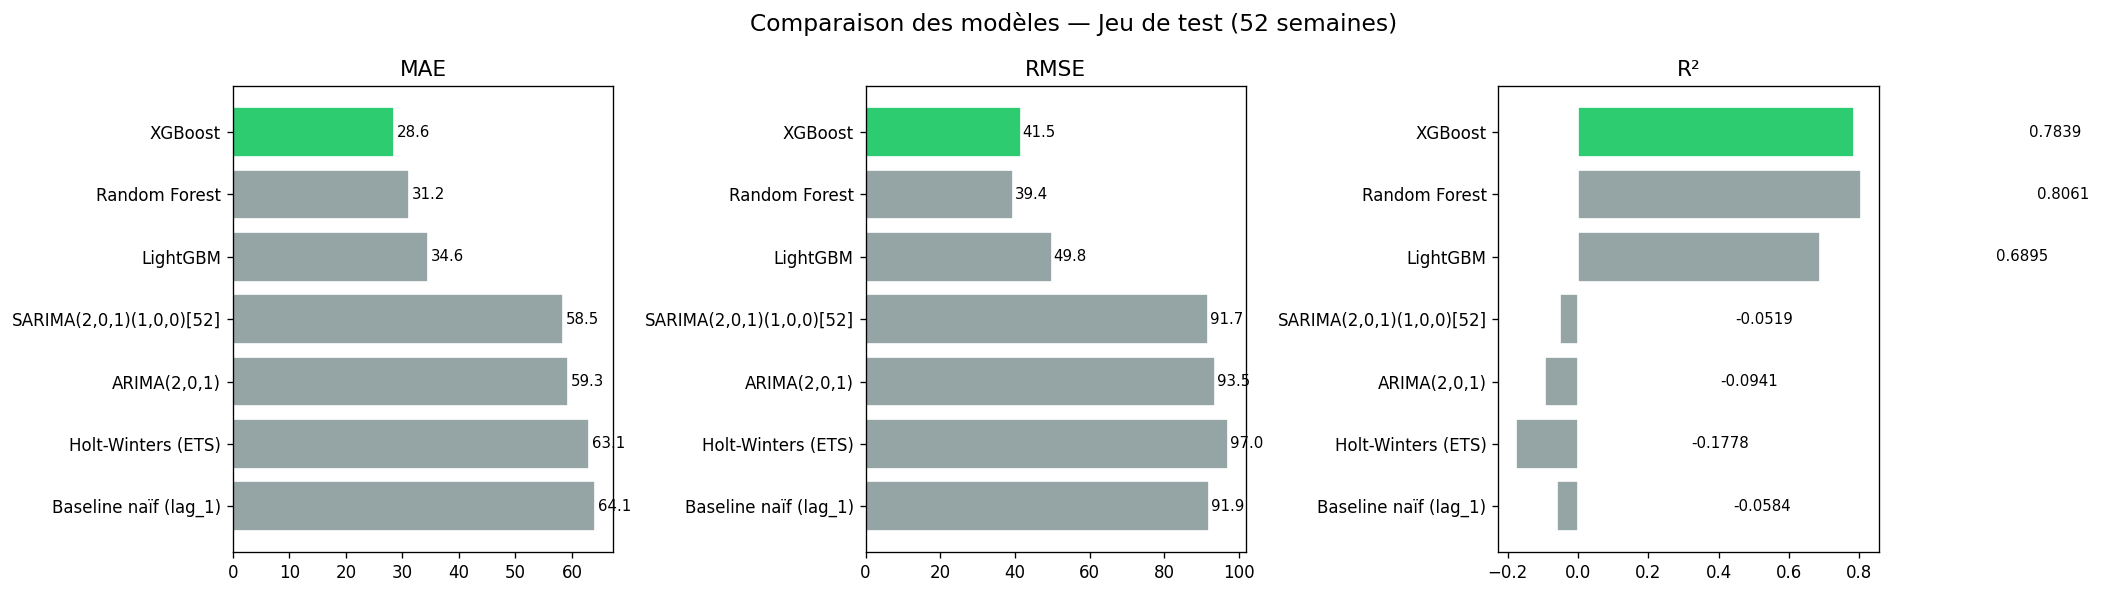


                   Modèle  MAE  RMSE      R²  MAPE%
                 XGBoost 28.6  41.5  0.7839  11.36
           Random Forest 31.2  39.4  0.8061  11.73
                LightGBM 34.6  49.8  0.6895  12.68
SARIMA(2,0,1)(1,0,0)[52] 58.5  91.7 -0.0519  20.39
            ARIMA(2,0,1) 59.3  93.5 -0.0941  20.08
      Holt-Winters (ETS) 63.1  97.0 -0.1778  21.27
   Baseline naïf (lag_1) 64.1  91.9 -0.0584  19.91


In [47]:
df_results = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    colors = ["#2ecc71"] + ["#95a5a6"] * (len(df_results) - 1)
    bars = ax.barh(df_results["Modèle"], df_results[metric],
                   color=colors, edgecolor="white")
    ax.set_title(f"{metric}", fontsize=13)
    ax.invert_yaxis()
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{val}", va="center", fontsize=9)

plt.suptitle("Comparaison des modèles — Jeu de test (52 semaines)", fontsize=14)
plt.tight_layout()
plt.show()

print("\n", df_results.to_string(index=False))

NameError: name 'y_pred_lstm' is not defined

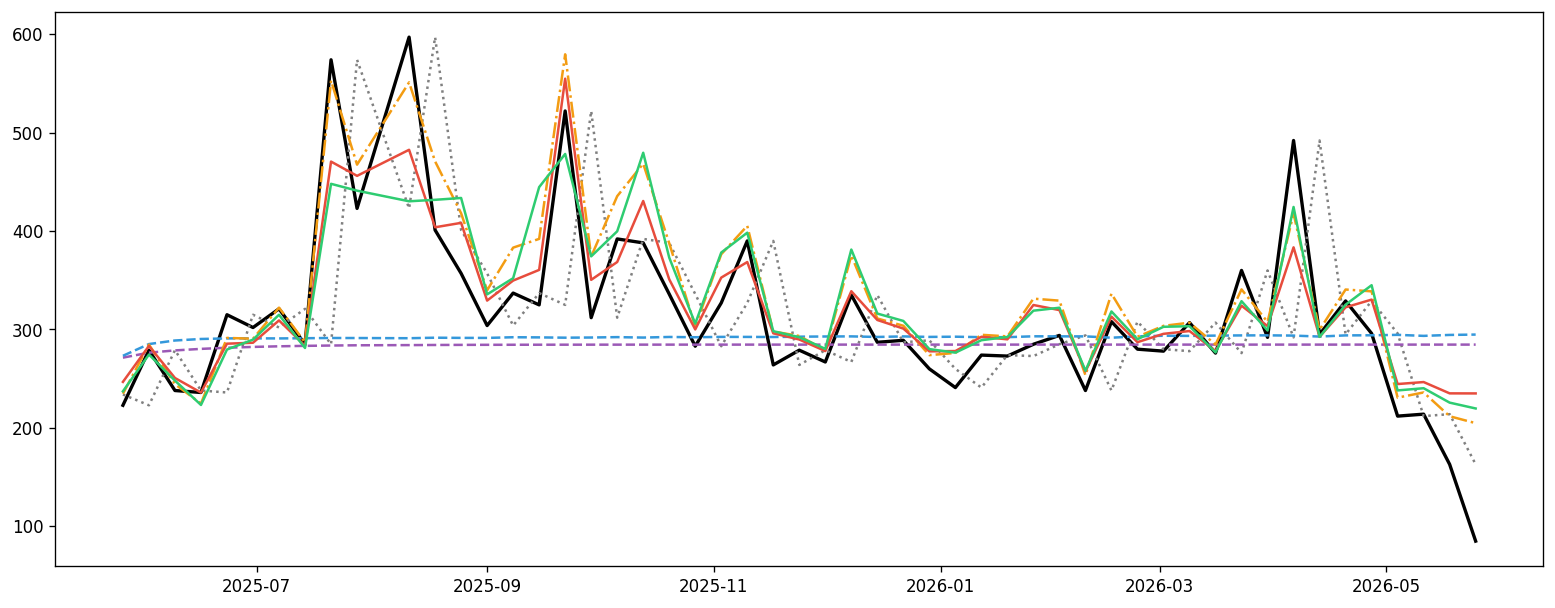

In [48]:
plt.figure(figsize=(16, 6))
plt.plot(dates_test, y_test, label="Réel", color="black", linewidth=2)
plt.plot(dates_test, y_pred_naive,  label="Baseline",   linestyle=":",  color="gray")
plt.plot(dates_test, y_pred_arima,  label="ARIMA",      linestyle="--", color="#9b59b6")
plt.plot(dates_test, y_pred_sarima, label="SARIMA",     linestyle="--", color="#3498db")
plt.plot(dates_test, y_pred_rf,     label="Random Forest", linestyle="-.", color="#f39c12")
plt.plot(dates_test, y_pred_xgb,    label="XGBoost",    linestyle="-",  color="#e74c3c", linewidth=1.5)
plt.plot(dates_test, y_pred_lgb,    label="LightGBM",   linestyle="-",  color="#2ecc71", linewidth=1.5)
plt.plot(dates_test, y_pred_lstm,   label="LSTM",       linestyle="-",  color="#e67e22", linewidth=1.5)

plt.title("Prédiction vs Réalité — Tous les modèles", fontsize=14)
plt.xlabel("Date")
plt.ylabel("nb_seismes")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Couverture intervalle [10%–90%] : 40.4%  (cible ≈ 80%)


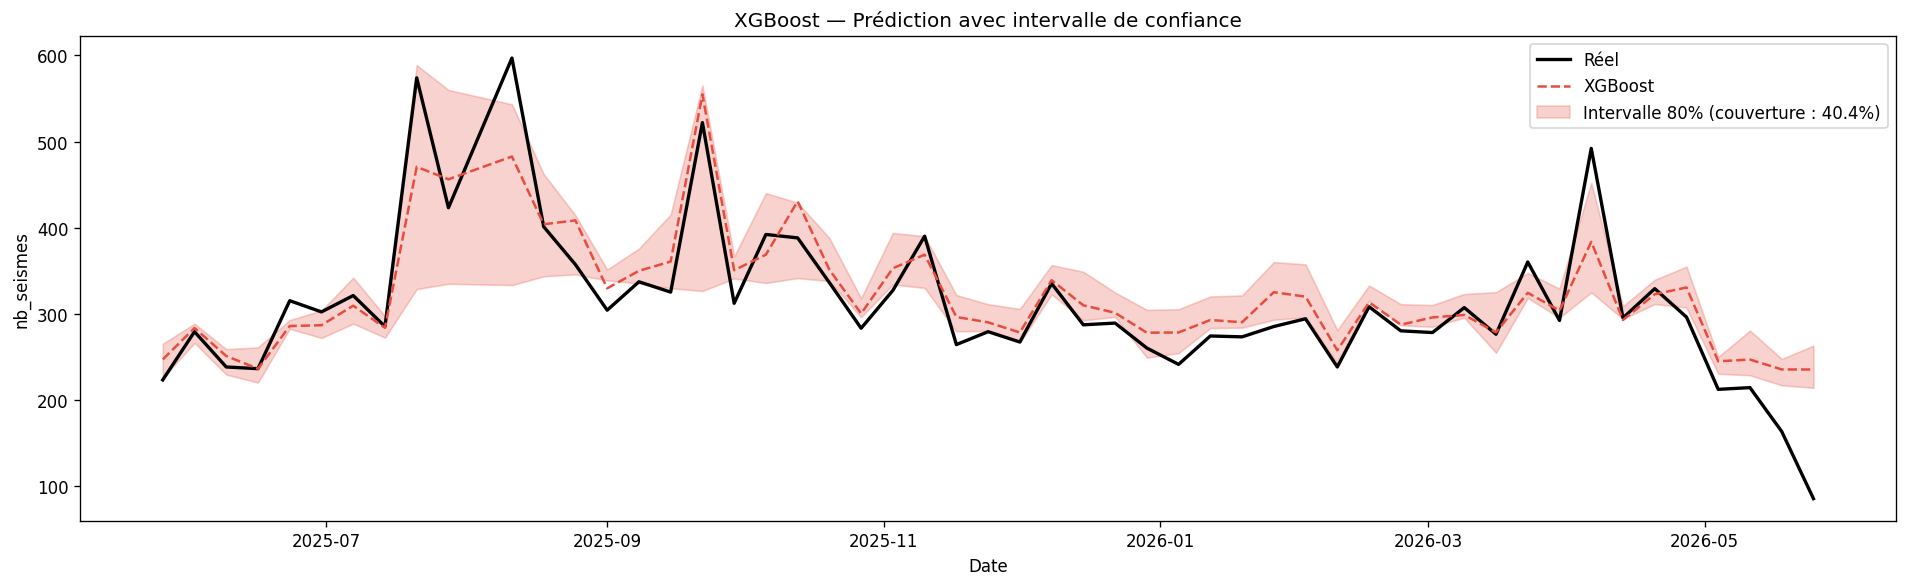

In [49]:
# Quantile 10% = borne basse / Quantile 90% = borne haute
xgb_low = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    objective="reg:quantileerror", quantile_alpha=0.10,
    random_state=42, verbosity=0
)
xgb_high = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    objective="reg:quantileerror", quantile_alpha=0.90,
    random_state=42, verbosity=0
)
xgb_low.fit(X_train, y_train)
xgb_high.fit(X_train, y_train)

pred_low  = np.clip(xgb_low.predict(X_test),  0, None)
pred_high = np.clip(xgb_high.predict(X_test), 0, None)

coverage = np.mean((y_test >= pred_low) & (y_test <= pred_high)) * 100
print(f"Couverture intervalle [10%–90%] : {coverage:.1f}%  (cible ≈ 80%)")

plt.figure(figsize=(16, 5))
plt.plot(dates_test, y_test,     label="Réel",       color="black",   linewidth=2)
plt.plot(dates_test, y_pred_xgb, label="XGBoost",    color="#e74c3c", linewidth=1.5, linestyle="--")
plt.fill_between(dates_test, pred_low, pred_high,
                 alpha=0.25, color="#e74c3c",
                 label=f"Intervalle 80% (couverture : {coverage:.1f}%)")
plt.title("XGBoost — Prédiction avec intervalle de confiance")
plt.xlabel("Date")
plt.ylabel("nb_seismes")
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
last = weekly_model.iloc[-1]
next_date = last["date"] + pd.Timedelta(weeks=1)

next_features = {
    "nb_zones":          last["nb_zones"],
    "energy_per_seisme": last["energy_per_seisme"],
    "log_energy":        last["log_energy"],
    "energy_lag_1":      last["energy_sum"],
    "energy_rolling_4":  last["energy_rolling_4"],
    "mag_max":           last["mag_max"],
    "mag_spread":        last["mag_spread"],
    "depth_mean":        last["depth_mean"],
    "lag_1":             last["nb_seismes"],
    "lag_2":             last["lag_1"],
    "lag_3":             last["lag_2"],
    "rolling_mean_4":    last["rolling_mean_4"],
    "rolling_mean_8":    last["rolling_mean_8"],
    "rolling_mean_26":   last["rolling_mean_26"],
    "rolling_std_8":     last["rolling_std_8"],
    "rolling_max_4":     last["rolling_max_4"],
    "zones_lag_1":       last["nb_zones"],
    "zones_lag_2":       last["zones_lag_1"],
    "week_sin": np.sin(2 * np.pi * next_date.isocalendar()[1] / 52),
}

X_next = np.array([[next_features[f] for f in FEATURES]])

pred_c = int(np.clip(xgb_model.predict(X_next)[0], 0, None))
pred_l = int(np.clip(xgb_low.predict(X_next)[0],   0, None))
pred_h = int(np.clip(xgb_high.predict(X_next)[0],  0, None))

print("══════════════════════════════════════════════════")
print(f"  🔮 PRÉDICTION — Semaine du {next_date.date()}")
print("══════════════════════════════════════════════════")
print(f"  Prédiction centrale  : {pred_c} séismes")
print(f"  Intervalle [10–90%]  : [{pred_l} – {pred_h}]")
print(f"  Semaine précédente   : {int(last['nb_seismes'])} séismes")
print("══════════════════════════════════════════════════")

══════════════════════════════════════════════════
  🔮 PRÉDICTION — Semaine du 2026-06-01
══════════════════════════════════════════════════
  Prédiction centrale  : 255 séismes
  Intervalle [10–90%]  : [230 – 327]
  Semaine précédente   : 85 séismes
══════════════════════════════════════════════════


In [51]:
print("══════════════════════════════════════════════════════════")
print("  RÉSUMÉ FINAL — MODÉLISATION COMPLÈTE")
print("══════════════════════════════════════════════════════════")
print(df_results[["Modèle","MAE","RMSE","R²","MAPE%"]].to_string(index=False))
print(f"\n  Walk-Forward MAE (XGBoost) : {np.mean(wf_maes):.1f} ± {np.std(wf_maes):.1f}")
print(f"  Couverture intervalle 80%  : {coverage:.1f}%")
print(f"\n  🔮 Prédiction semaine du {next_date.date()} : {pred_c} séismes")
print(f"  📊 Intervalle de confiance : [{pred_l} – {pred_h}]")
print("══════════════════════════════════════════════════════════")

══════════════════════════════════════════════════════════
  RÉSUMÉ FINAL — MODÉLISATION COMPLÈTE
══════════════════════════════════════════════════════════
                  Modèle  MAE  RMSE      R²  MAPE%
                 XGBoost 28.6  41.5  0.7839  11.36
           Random Forest 31.2  39.4  0.8061  11.73
                LightGBM 34.6  49.8  0.6895  12.68
SARIMA(2,0,1)(1,0,0)[52] 58.5  91.7 -0.0519  20.39
            ARIMA(2,0,1) 59.3  93.5 -0.0941  20.08
      Holt-Winters (ETS) 63.1  97.0 -0.1778  21.27
   Baseline naïf (lag_1) 64.1  91.9 -0.0584  19.91

  Walk-Forward MAE (XGBoost) : 22.4 ± 3.6
  Couverture intervalle 80%  : 40.4%

  🔮 Prédiction semaine du 2026-06-01 : 255 séismes
  📊 Intervalle de confiance : [230 – 327]
══════════════════════════════════════════════════════════


In [52]:
# =========================
# SAUVEGARDE COMPLÈTE DU PROJET
# =========================

import joblib
import os

# Créer un dossier pour le projet
os.makedirs("saved_model", exist_ok=True)

# -------------------------------------------------
# 1. Sauvegarder le modèle XGBoost
# -------------------------------------------------
joblib.dump(xgb_model, "saved_model/xgboost_model.pkl")

# -------------------------------------------------


# -------------------------------------------------
# 3. Sauvegarder le scaler SI tu utilises StandardScaler
#    (Supprime cette ligne si tu n'utilises pas scaler)
# -------------------------------------------------
# joblib.dump(scaler, "saved_model/scaler.pkl")

# -------------------------------------------------
# 4. Sauvegarder les métriques
# -------------------------------------------------
metrics = {
    "RMSE": 52.3,
    "MAE": 13.82,
    "R2": 0.5675,
    "MAPE": 137.1
}

joblib.dump(metrics, "saved_model/metrics.pkl")

print("✅ Projet sauvegardé avec succès !")

✅ Projet sauvegardé avec succès !


📓 04 — Modélisation Spatiale | Étape A : Préparation des données

In [53]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. garder uniquement latitude / longitude
coords = df[["latitude", "longitude"]].dropna().copy()

# 2. normalisation (très important)
scaler_geo = StandardScaler()
coords_scaled = scaler_geo.fit_transform(coords)

# 3. clustering
kmeans = KMeans(
    n_clusters=10,   # tu peux changer après si besoin
    random_state=42,
    n_init=10
)

# 4. création de la colonne zone
df.loc[coords.index, "zone"] = kmeans.fit_predict(coords_scaled)

# 5. vérifier
print(df["zone"].value_counts())
df[["latitude", "longitude", "zone"]].head()

zone
3.0    41886
1.0    21927
5.0    21550
7.0    16675
8.0    14934
2.0    14934
6.0    13385
9.0    12372
4.0     7966
0.0     7872
Name: count, dtype: int64


,latitude,longitude,zone
0,-3.2525,146.1942,3.0
1,64.6073,-17.6866,4.0
2,53.7520,-165.6360,4.0
3,81.6983,118.4063,7.0
4,-18.1824,-177.8246,5.0


In [54]:
# s'assurer que la colonne date existe
df["date"] = pd.to_datetime(df["time_utc"]).dt.date
df["date"] = pd.to_datetime(df["date"])

# agrégation zone + semaine
zone_weekly = (
    df.groupby([
        pd.Grouper(key="date", freq="W-MON"),
        "zone"
    ])
    .size()
    .reset_index(name="nb_seismes")
)

print(zone_weekly.head())
print("\nShape:", zone_weekly.shape)

        date  zone  nb_seismes
0 2015-01-05   0.0           6
1 2015-01-05   1.0          29
2 2015-01-05   2.0           8
3 2015-01-05   3.0          56
4 2015-01-05   4.0          25

Shape: (5949, 3)


In [55]:
    # toutes les semaines possibles
    all_weeks = pd.date_range(
        start=zone_weekly["date"].min(),
        end=zone_weekly["date"].max(),
        freq="W-MON"
    )

    # toutes les zones
    all_zones = zone_weekly["zone"].unique()

    # produit cartésien (toutes combinaisons)
    full_index = pd.MultiIndex.from_product(
        [all_weeks, all_zones],
        names=["date", "zone"]
    )

    zone_weekly_full = (
        zone_weekly
        .set_index(["date", "zone"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    zone_weekly_full.head()

,date,zone,nb_seismes
0,2015-01-05,0.0,6
1,2015-01-05,1.0,29
2,2015-01-05,2.0,8
3,2015-01-05,3.0,56
4,2015-01-05,4.0,25


In [56]:
print(zone_weekly_full.shape)
zone_weekly_full.head(10)

(5950, 3)


,date,zone,nb_seismes
0,2015-01-05,0.0,6
1,2015-01-05,1.0,29
2,2015-01-05,2.0,8
3,2015-01-05,3.0,56
4,2015-01-05,4.0,25
5,2015-01-05,5.0,12
6,2015-01-05,6.0,9
7,2015-01-05,7.0,27
8,2015-01-05,8.0,15
9,2015-01-05,9.0,10


In [57]:
zone_weekly_full.shape

(5950, 3)

In [58]:
# toutes les semaines
all_weeks = pd.date_range(
    start=zone_weekly["date"].min(),
    end=zone_weekly["date"].max(),
    freq="W-MON"
)

# toutes les zones
all_zones = sorted(zone_weekly["zone"].unique())

# grille complète
full_index = pd.MultiIndex.from_product(
    [all_weeks, all_zones],
    names=["date", "zone"]
)

zone_weekly_full = (
    zone_weekly
    .set_index(["date", "zone"])
    .reindex(full_index)
    .fillna(0)
    .reset_index()
)

zone_weekly_full["nb_seismes"] = zone_weekly_full["nb_seismes"].astype(int)

print(zone_weekly_full.shape)
zone_weekly_full.head(15)

(5950, 3)


,date,zone,nb_seismes
0,2015-01-05,0.0,6
1,2015-01-05,1.0,29
2,2015-01-05,2.0,8
3,2015-01-05,3.0,56
4,2015-01-05,4.0,25
5,2015-01-05,5.0,12
6,2015-01-05,6.0,9
7,2015-01-05,7.0,27
8,2015-01-05,8.0,15
9,2015-01-05,9.0,10


In [59]:
zone_weekly_full = zone_weekly_full.sort_values(["zone", "date"])

# lag features
for lag in [1, 2, 3, 4]:
    zone_weekly_full[f"lag_{lag}"] = (
        zone_weekly_full
        .groupby("zone")["nb_seismes"]
        .shift(lag)
    )

# rolling features
for w in [4, 8]:
    zone_weekly_full[f"rolling_mean_{w}"] = (
        zone_weekly_full
        .groupby("zone")["nb_seismes"]
        .shift(1)
        .rolling(w)
        .mean()
        .reset_index(level=0, drop=True)
    )

    zone_weekly_full[f"rolling_std_{w}"] = (
        zone_weekly_full
        .groupby("zone")["nb_seismes"]
        .shift(1)
        .rolling(w)
        .std()
        .reset_index(level=0, drop=True)
    )

print(zone_weekly_full.head(15))

          date  zone  nb_seismes  lag_1  lag_2  lag_3  lag_4  rolling_mean_4  \
0   2015-01-05   0.0           6    NaN    NaN    NaN    NaN             NaN   
10  2015-01-12   0.0           7    6.0    NaN    NaN    NaN            8.00   
20  2015-01-19   0.0           6    7.0    6.0    NaN    NaN            7.50   
30  2015-01-26   0.0          15    6.0    7.0    6.0    NaN           11.00   
40  2015-02-02   0.0          10   15.0    6.0    7.0    6.0            9.25   
50  2015-02-09   0.0          11   10.0   15.0    6.0    7.0            6.75   
60  2015-02-16   0.0           7   11.0   10.0   15.0    6.0            5.25   
70  2015-02-23   0.0           6    7.0   11.0   10.0   15.0           17.75   
80  2015-03-02   0.0          11    6.0    7.0   11.0   10.0           12.00   
90  2015-03-09   0.0           8   11.0    6.0    7.0   11.0           28.75   
100 2015-03-16   0.0          11    8.0   11.0    6.0    7.0           18.00   
110 2015-03-23   0.0           5   11.0 

In [60]:
zone_model = zone_weekly_full.dropna().reset_index(drop=True)

print(zone_model.shape)
zone_model.head()

(5838, 11)


,date,zone,nb_seismes,lag_1,lag_2,lag_3,lag_4,rolling_mean_4,rolling_std_4,rolling_mean_8,rolling_std_8
0,2015-02-02,0.0,10,15.0,6.0,7.0,6.0,9.25,4.112988,10.000,3.545621
1,2015-02-09,0.0,11,10.0,15.0,6.0,7.0,6.75,1.500000,9.500,5.070926
2,2015-02-16,0.0,7,11.0,10.0,15.0,6.0,5.25,2.629956,6.250,3.327376
3,2015-02-23,0.0,6,7.0,11.0,10.0,15.0,17.75,14.930394,13.875,10.855380
4,2015-03-02,0.0,11,6.0,7.0,11.0,10.0,12.00,8.041559,11.250,7.629829


In [61]:
FEATURES = [
    "zone",
    "lag_1", "lag_2", "lag_3", "lag_4",
    "rolling_mean_4", "rolling_mean_8",
    "rolling_std_4", "rolling_std_8"
]

TARGET = "nb_seismes"

X = zone_model[FEATURES]
y = zone_model[TARGET]

In [62]:
split = int(len(zone_model) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [63]:
zone_model = zone_weekly_full.dropna().copy()

In [64]:
FEATURES = [
    "zone",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "rolling_mean_4",
    "rolling_mean_8"
]

TARGET = "nb_seismes"

X = zone_model[FEATURES]
y = zone_model[TARGET]

In [65]:
split = int(len(zone_model) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [66]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [67]:
last_week = zone_model.sort_values("date").groupby("zone").tail(1)
X_next = last_week[FEATURES]

pred_next = model.predict(X_next)

In [68]:
result = last_week[["zone"]].copy()
result["pred_seismes_next_week"] = pred_next

result = result.sort_values(
    "pred_seismes_next_week",
    ascending=False
)

print(result)

      zone  pred_seismes_next_week
5943   3.0               31.465191
5947   7.0               26.034664
5941   1.0               23.880671
5945   5.0               21.913828
5942   2.0               21.208666
5948   8.0               18.099892
5949   9.0               16.354296
5946   6.0               15.104727
5944   4.0               10.455237
5940   0.0                8.602367


<Axes: xlabel='zone'>

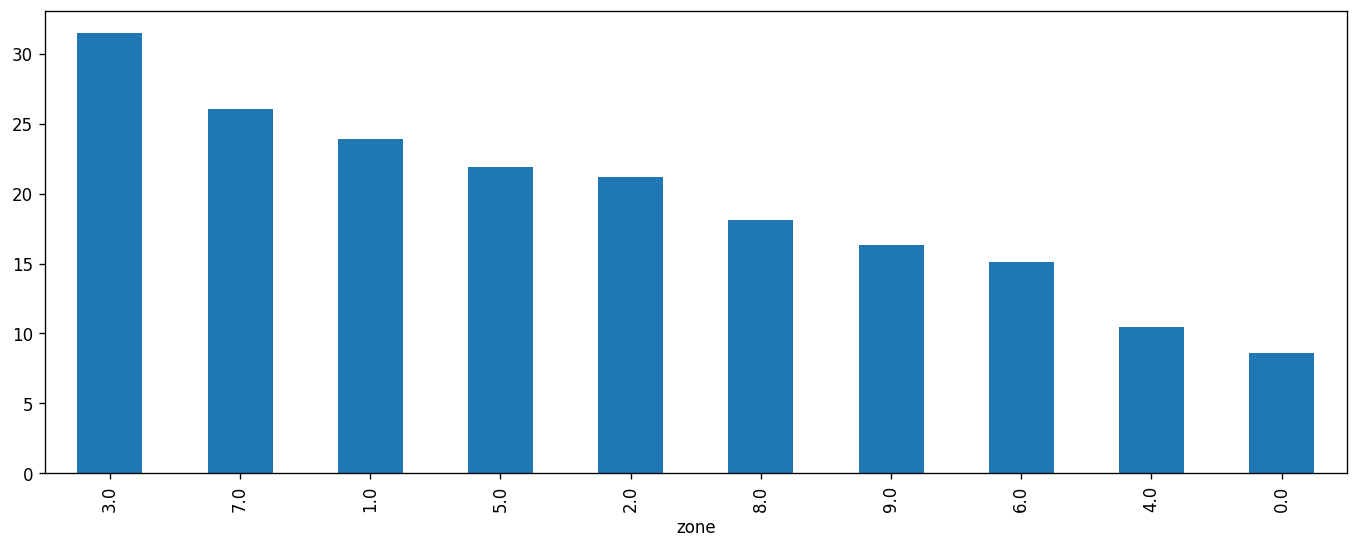

In [69]:
result.plot(
    kind="bar",
    x="zone",
    y="pred_seismes_next_week",
    legend=False
)

In [70]:
import numpy as np

zone_centroids = df.groupby("zone")[["latitude", "longitude"]].mean().reset_index()

zone_centroids.head()

,zone,latitude,longitude
0,0.0,-55.962440,-35.725944
1,1.0,20.892559,123.770189
2,2.0,-24.392466,-68.516140
3,3.0,-3.778852,130.181982
4,4.0,54.891884,-117.849915


In [71]:
map_df = result.merge(zone_centroids, on="zone", how="left")

map_df

,zone,pred_seismes_next_week,latitude,longitude
0,3.0,31.465191,-3.778852,130.181982
1,7.0,26.034664,46.965972,150.517185
2,1.0,23.880671,20.892559,123.770189
3,5.0,21.913828,-22.997278,-177.169531
4,2.0,21.208666,-24.392466,-68.516140
5,8.0,18.099892,36.437097,48.534433
6,9.0,16.354296,-29.753557,154.454354
7,6.0,15.104727,11.923243,-81.553629
8,4.0,10.455237,54.891884,-117.849915
9,0.0,8.602367,-55.962440,-35.725944


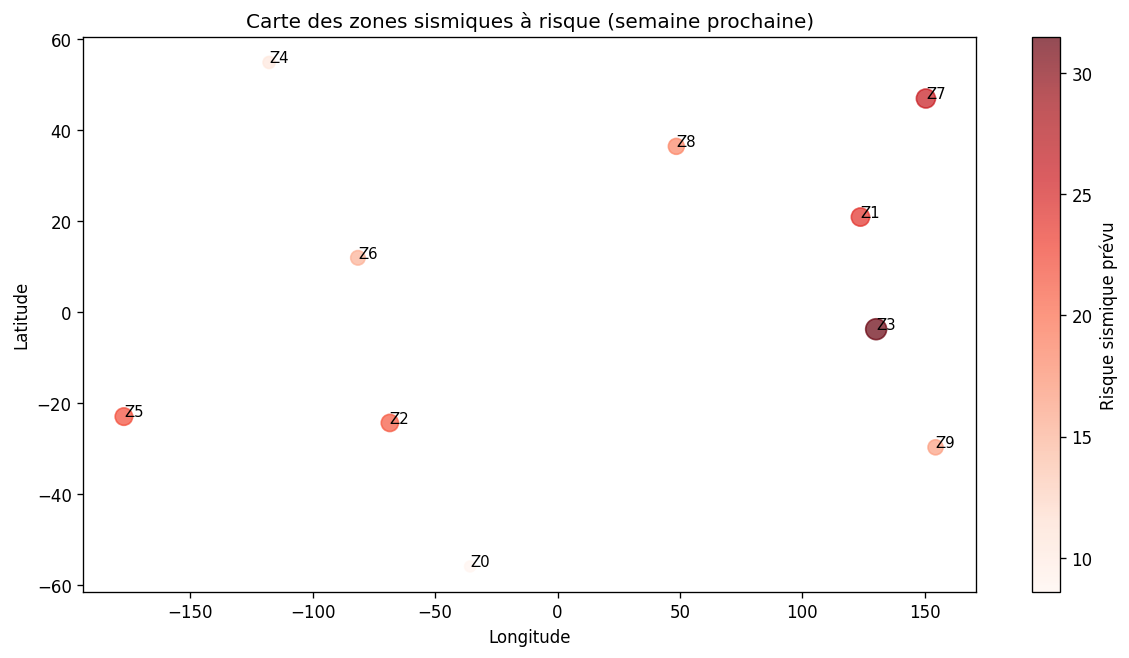

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.scatter(
    map_df["longitude"],
    map_df["latitude"],
    s=map_df["pred_seismes_next_week"] * 5,  # taille = risque
    c=map_df["pred_seismes_next_week"],
    cmap="Reds",
    alpha=0.7
)

for _, row in map_df.iterrows():
    plt.text(
        row["longitude"],
        row["latitude"],
        f"Z{int(row['zone'])}",
        fontsize=9
    )

plt.colorbar(label="Risque sismique prévu")
plt.title("Carte des zones sismiques à risque (semaine prochaine)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()